# 2 — Predicting interior temperature & humidity (multi-objective, multi-horizon)

**Goal.** Given everything we know about the greenhouse *now*, predict **interior temperature** and **interior humidity** (centre sensor) at three lead times — **+1 h**, **+6 h**, **+12 h** — i.e. **6 quantities at once** (2 variables × 3 horizons): a *multi-objective* regression.

**Special focus of this version: the climatic systems.** The heaters, fog, pumps, blower, recirculators, shade screens and vents in `inside data resampled/` are all included as features. Two design choices make sure they get a *fair* chance to matter, and one analysis *measures* whether they get matter:

1. **Scope to the active period.** Those systems only begin logging in spring; before that their columns are all-zero, which unfairly dilutes them. We restrict the whole study to **from `ACTIVE_START` (2026-04-24)**, when *every* climatic system is online — so they are present in both the train and the test split.
2. **Actuator history features.** A single hour of "on-minutes" is a weak signal; because of thermal/humidity inertia what matters is *how long a device has been running*. We add rolling sums over the last **3 h and 6 h** for every actuator.
3. **Ablation.** We build an escalating ladder of feature sets — *no actuators → + current actuators → + actuator history → + cluster* — and measure the MAE at each rung. That tells us the **marginal value** of the climatic-system data instead of just asserting it.
4. **Fair sequence comparison.** The LSTM originally saw a 24-hour window per prediction while the tabular models saw only the current hour — not an apples-to-apples comparison of *architecture*. Section 2.7c feeds Ridge/RandomForest/HistGB the exact same flattened 24h window the LSTM gets (the `"... (24h hist)"` model variants), and 2.7e / 2.7g / 2.7i / 2.7k each add a `lookback=1` (t-only) variant of one of the sequence architectures, to match the tabular baseline the other way — completing a grid of **{tabular, LSTM, GRU, Attention, MLP} × {t only, 24h history}**, so 2.8 can separate a *history* effect from an *architecture* effect across five different architectures, not just two.
5. **Attention-based architecture, plus GRU and MLP, all under the same fairness rules.** 2.7f/2.7g add a compact attention-based sequence model — one multi-head self-attention block over the 24h window, loosely in the spirit of Temporal Fusion Transformer (TFT) architectures, but deliberately *not* a full TFT (see the note in 2.7f for why: with ~1.2k training rows, a full TFT's variable-selection networks, gating and quantile loss would mostly add parameters to overfit with). 2.7h/2.7i add a **GRU** — a simpler-gated recurrent alternative to the LSTM — and 2.7j/2.7k add a plain **MLP** (a flatten-and-Dense feed-forward baseline with no notion of order at all), so the grid spans a non-sequence-aware neural baseline, two recurrent architectures and an attention-based one. Every one of them is built from the exact same `make_sequences()` windows, split, targets and metrics as the LSTM, so every pairwise gap in 2.8 is an architecture-only comparison.
6. **Day-ahead weather forecast, aligned per horizon — and only that.** `forecast data/hourly_weather_data.csv` carries two kinds of Open-Meteo values: the un-suffixed columns (`FORECAST_FEATURE_COLS`) turn out to be satellite/model "latest run" estimates rather than a genuine advance forecast, so they are **excluded from every model input** (2.3). Only the `*_previous_day1` columns — issued with real ~1-day lead time — are used, aligned per horizon (the `+ day-ahead forecast` rung).
7. **Hyperparameter tuning — a small manual grid for the tabular models, Bayesian optimization for the neural ones.** Ridge/RandomForest/HistGB (2.7b/2.7c) still search a small fixed grid (`alpha`, `min_samples_leaf`, `learning_rate`). Every neural architecture — LSTM, GRU, Attention and MLP (2.7d–2.7k) — is tuned with **KerasTuner's `BayesianOptimization` tuner** instead (`tune_neural()`, 2.7d): rather than trying a fixed list of configurations, it searches `units`, `dropout`, learning rate and `optimizer` as a proper mixed continuous/categorical space, picking each new candidate from a probabilistic model of what is likely to work well given the trials already run. All of it is scored on a chronological hold-out carved from the end of `train`. 2.7l shows what won for each model × rung. Requires `pip install keras-tuner`.

**Two rules that keep the evaluation honest**
* **No leakage** — every feature is known at prediction time (current sensors/actuators, outside weather, the cluster label, and — from the `+ day-ahead forecast` rung on — a forecast with a real lead time). The un-suffixed Open-Meteo `fc_*` columns are not fed to any model (2.3), since they are not genuinely known that far in advance. The hyperparameter search in 2.7b–2.7g is likewise scored on an inner hold-out carved from `train` only — `test` is never touched until final scoring.
* **Chronological split** — train on the earlier period, test on the later one. Never shuffle a time series.


In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import (mean_absolute_error, root_mean_squared_error, r2_score,
                            precision_score, recall_score, f1_score,
                            average_precision_score, confusion_matrix)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt

from greenhouse_dataset import (
    build_hourly_dataset, add_actuator_history, make_targets, TARGET_COLS,
    ACTIVE_START, CONTINUOUS_COLS, ACTUATOR_COLS, EXTERIOR_COLS,
    FORECAST_PREVDAY_FEATURE_COLS, make_forecast_horizon_features,
)

pd.set_option("display.width", 150)
plt.rcParams["figure.figsize"] = (11, 4)


## 2.1 — Load, add actuator history, scope to the active period, attach clusters

We build the hourly table, add the rolling actuator-history columns (`act_*_r3`, `act_*_r6`), then cut everything to the window where the climatic systems are actually operating. We also add the day-ahead forecast, aligned per horizon (`make_forecast_horizon_features`, see 2.3 for why). Finally we join the cluster labels from notebook 1 and one-hot encode them.


In [2]:
df = build_hourly_dataset(root=".")
hist_cols = add_actuator_history(df, windows=(3, 6))     # act_*_r3, act_*_r6
print(f"added {len(hist_cols)} actuator-history features, e.g. {hist_cols[:4]}")

df = df.loc[ACTIVE_START:]                                # <-- re-scope
print("active-period span:", df.index.min(), "->", df.index.max(), "|", len(df), "hours")

clusters = pd.read_csv("model data/clusters.csv", index_col=0, parse_dates=True)["cluster"]
cluster_ohe = pd.get_dummies(clusters, prefix="clu").astype(float)
df = df.join(cluster_ohe)
cluster_cols = list(cluster_ohe.columns)
df[cluster_cols] = df[cluster_cols].fillna(0.0)
print("cluster dummies present in window:",
      [c for c in cluster_cols if df[c].sum() > 0])

fc_hist_cols = make_forecast_horizon_features(df, horizons=(1, 6, 12))
print(f"added {len(fc_hist_cols)} day-ahead forecast features, e.g. {fc_hist_cols[:4]}")


note: fc_temp_prevday still missing 364h after the short-gap fill; bridging with an unlimited forward-fill of its own past values (flagged in fc_temp_prevday_stale)
note: fc_hum_prevday still missing 364h after the short-gap fill; bridging with an unlimited forward-fill of its own past values (flagged in fc_hum_prevday_stale)
note: fc_viento_prevday still missing 260h after the short-gap fill; bridging with an unlimited forward-fill of its own past values (flagged in fc_viento_prevday_stale)
added 26 actuator-history features, e.g. ['act_calefactores_r3', 'act_calefactores_r6', 'act_fog_r3', 'act_fog_r6']
active-period span: 2026-04-24 00:00:00 -> 2026-07-13 22:00:00 | 1943 hours
cluster dummies present in window: ['clu_0', 'clu_1', 'clu_2', 'clu_3', 'clu_4', 'clu_5', 'clu_6', 'clu_7']
added 15 day-ahead forecast features, e.g. ['fc_temp_prevday_h1', 'fc_temp_prevday_h6', 'fc_temp_prevday_h12', 'fc_hum_prevday_h1']


c:\Users\psyey\OneDrive\Escritorio\Git_repos\Osiris-Greenhouse-UMU\greenhouse_dataset.py:340: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[name] = df[col].shift(-h)


In [3]:
df

,temp_alta,temp_baja,temp_centro,hum_alta,hum_baja,hum_centro,pres_baro_alta,pres_baro_baja,pres_baro_centro,pres_vapor_alta,...,fc_hum_prevday_h12,fc_precip_prevday_h1,fc_precip_prevday_h6,fc_precip_prevday_h12,fc_viento_prevday_h1,fc_viento_prevday_h6,fc_viento_prevday_h12,fc_rad_prevday_h1,fc_rad_prevday_h6,fc_rad_prevday_h12
time,,,,,,,,,,,,,,,,,,,,,
2026-04-24 00:00:00,16.907527,16.618750,16.626281,73.472222,76.136364,77.181579,100.593514,100.632051,1008.412526,1.412813,...,39.414593,0.0,0.0,0.0,0.111803,1.484924,0.316228,0.0,15.0,706.0
2026-04-24 01:00:00,16.220588,15.827835,15.904775,74.708333,77.970588,78.686071,100.526867,100.566410,1007.771099,1.376735,...,47.167670,0.0,0.0,0.1,0.364005,1.414214,0.604152,0.0,118.0,490.0
2026-04-24 02:00:00,15.708511,15.417476,15.435217,75.117647,77.753425,78.876319,100.502821,100.543514,1007.533452,1.342500,...,63.458977,0.0,0.0,0.6,0.721110,1.167262,1.051190,0.0,219.0,275.0
2026-04-24 03:00:00,15.448598,15.127083,15.177257,74.985714,76.945205,77.909934,100.523247,100.564691,1007.750591,1.310841,...,70.109750,0.0,0.0,1.1,1.101136,0.848528,1.569236,0.0,329.0,189.0
2026-04-24 04:00:00,14.947115,14.654808,14.733860,76.325301,78.300000,79.391233,100.539205,100.582532,1007.914021,1.296863,...,75.221120,0.0,0.0,1.4,1.379311,0.531507,2.089258,0.0,328.0,89.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-13 18:00:00,32.484536,31.639175,32.048163,57.494118,62.612903,62.140490,100.129130,100.167619,1004.055155,2.815593,...,NaN,0.0,NaN,NaN,3.696282,NaN,NaN,102.0,NaN,NaN
2026-07-13 19:00:00,30.364130,30.381522,30.502536,62.362319,63.805970,63.968864,100.197500,100.238696,1004.722423,2.713611,...,NaN,0.0,NaN,NaN,2.294014,NaN,NaN,6.0,NaN,NaN
2026-07-13 20:00:00,29.073864,29.028889,29.169756,65.698413,67.898551,67.379215,100.257059,100.299559,1005.318446,2.639541,...,NaN,0.0,NaN,NaN,1.140176,NaN,NaN,0.0,NaN,NaN


## 2.2 — Build the targets

Shift the centre temperature and humidity **back** by each horizon so row *t* carries the value observed at *t+h*.

In [4]:
targets = make_targets(df, temp_col="temp_centro", hum_col="hum_centro",
                       horizons=(1, 6, 12))
print("targets:", TARGET_COLS)
targets.head()

targets: ['temp_h1', 'hum_h1', 'temp_h6', 'hum_h6', 'temp_h12', 'hum_h12']


,temp_h1,hum_h1,temp_h6,hum_h6,temp_h12,hum_h12
time,,,,,,
2026-04-24 00:00:00,15.904775,78.686071,14.899074,79.809038,25.457528,45.066298
2026-04-24 01:00:00,15.435217,78.876319,15.373333,77.426667,25.873268,44.463548
2026-04-24 02:00:00,15.177257,77.909934,21.561975,55.423788,25.412527,44.783048
2026-04-24 03:00:00,14.733860,79.391233,25.838929,45.972019,24.535730,53.939559
2026-04-24 04:00:00,14.219767,80.987760,25.925117,44.604641,21.387315,69.703302


## 2.3 — Feature sets: the ablation ladder

Every rung adds one more group of information on top of the previous one, so the change in error isolates each group's contribution:

| rung | contents |
|---|---|
| **no actuators** | interior climate + exterior weather + time |
| **+ actuators (current)** | above **+** this-hour on-minutes of each climatic system |
| **+ actuator history** | above **+** rolling 3 h / 6 h running totals |
| **+ cluster** | above **+** the regime label from notebook 1 |
| **+ day-ahead forecast** | above **+** the `previous_day1` forecast value for the *target* hour t+h, one column per variable per horizon |

The *climate* block already contains the interior temperature/humidity/pressure, so it is a strong base — the question is how much the **climatic-system** blocks add on top.

**`FORECAST_FEATURE_COLS` is deliberately excluded from `climate`.** The un-suffixed Open-Meteo columns (`fc_temp`, `fc_hum`, `fc_precip`, `fc_viento`, `fc_rad`) come from the Open-Meteo *Previous Runs API*'s "latest available run" for each timestamp — for a date now in the past, that's effectively the most recent satellite/model-blended estimate, not something forecastable with real lead time on the day itself. `greenhouse_dataset.py` still reads them for reference, but they are **no longer fed to any model as a feature, and no longer used to backfill gaps in the `previous_day1` series either** — that fallback would have quietly broken the `previous_day1` lead-time guarantee for exactly the rows it patched. Where `previous_day1` has a real outage too long to bridge (e.g. `wind_speed_10m_previous_day1`'s ~260 h gap in Apr-May 2026), those hours are simply left `NaN` and excluded by the `dropna()` in the next cell (see the note in `greenhouse_dataset.py`).

**The only forecast information the models see is `previous_day1`.** Open-Meteo's `*_previous_day1` columns are the forecast values as issued by the model run from about a day before the target hour — a genuine, honestly-available-in-advance forecast. `make_forecast_horizon_features()` (2.1) builds one column per forecast variable per horizon, shifting each `previous_day1` series back by *h* exactly the way `make_targets()` builds the targets themselves — so row *t* carries "what was forecast a day ago for hour *t+h*". Since the horizons here (≤12h) are well inside that ~1-day lead time, this is safe: the forecast for *t+h* was already issued before *t*. That's what the **`+ day-ahead forecast`** rung uses — and now it's the only rung carrying any forecast-derived feature at all.


In [5]:
time_feats = ["hour_sin", "hour_cos", "doy_sin", "doy_cos", "hour", "month"]
climate = CONTINUOUS_COLS + EXTERIOR_COLS + time_feats   # FORECAST_FEATURE_COLS dropped, see 2.3

feature_sets = {
    "no actuators":           climate,
    "+ actuators (current)":  climate + ACTUATOR_COLS,
    "+ actuator history":     climate + ACTUATOR_COLS + hist_cols,
    "+ cluster":              climate + ACTUATOR_COLS + hist_cols + cluster_cols,
    "+ day-ahead forecast":   climate + ACTUATOR_COLS + hist_cols + cluster_cols + fc_hist_cols,
}
actuator_features = ACTUATOR_COLS + hist_cols     # everything "climatic-system"

# oracle_hist_cols: the ACTUAL future exterior weather (ext_temp/ext_hum/ext_rad_par/
# ext_viento, shifted to the target hour), used only by the "oracle" deployment-information
# regime in 2.14 as a non-deployable upper-bound benchmark -- NOT a model input for any
# feature-set rung above. Computed here, not in 2.14, so that any row lacking a genuine
# future observation (a raw sensor gap longer than the short-gap fill in
# greenhouse_dataset.py -- see the note there) is dropped from `data` up front, exactly
# like the day-ahead forecast columns already are below. That makes this ONE row set
# (train/test from 2.4 on) shared by literally everything that follows -- the persistence
# baseline (2.6), the full 2.7-2.13 architecture x feature-set grid, and every regime in
# 2.14 (snapshot/oracle trained fresh on it; historical/NWP reuse 2.7-2.8 predictions that
# were themselves trained on it) -- instead of oracle/snapshot alone seeing a slightly
# smaller training set than historical/NWP, as an earlier version of this notebook did.
oracle_hist_cols = make_forecast_horizon_features(df, horizons=(1, 6, 12), source_cols=EXTERIOR_COLS)
print(f"added {len(oracle_hist_cols)} oracle (real future exterior weather) features, e.g. {oracle_hist_cols[:4]}")

all_cols = climate + ACTUATOR_COLS + hist_cols + cluster_cols + fc_hist_cols + oracle_hist_cols
required = climate + ACTUATOR_COLS + hist_cols + fc_hist_cols + oracle_hist_cols   # cluster dummies may be 0
data = df[all_cols].join(targets).dropna(subset=required + TARGET_COLS)
print("modelling rows:", len(data), "| candidate features:", len(all_cols))


added 12 oracle (real future exterior weather) features, e.g. ['ext_temp_h1', 'ext_temp_h6', 'ext_temp_h12', 'ext_hum_h1']
modelling rows: 1456 | candidate features: 98


c:\Users\psyey\OneDrive\Escritorio\Git_repos\Osiris-Greenhouse-UMU\greenhouse_dataset.py:340: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[name] = df[col].shift(-h)


In [6]:
data

,temp_alta,temp_baja,temp_centro,hum_alta,hum_baja,hum_centro,pres_baro_alta,pres_baro_baja,pres_baro_centro,pres_vapor_alta,...,ext_rad_par_h12,ext_viento_h1,ext_viento_h6,ext_viento_h12,temp_h1,hum_h1,temp_h6,hum_h6,temp_h12,hum_h12
time,,,,,,,,,,,,,,,,,,,,,
2026-04-24 00:00:00,16.907527,16.618750,16.626281,73.472222,76.136364,77.181579,100.593514,100.632051,1008.412526,1.412813,...,273.060833,0.481656,0.897143,2.944518,15.904775,78.686071,14.899074,79.809038,25.457528,45.066298
2026-04-24 01:00:00,16.220588,15.827835,15.904775,74.708333,77.970588,78.686071,100.526867,100.566410,1007.771099,1.376735,...,150.258333,1.025596,0.236667,3.597064,15.435217,78.876319,15.373333,77.426667,25.873268,44.463548
2026-04-24 02:00:00,15.708511,15.417476,15.435217,75.117647,77.753425,78.876319,100.502821,100.543514,1007.533452,1.342500,...,134.006667,1.043714,0.611684,2.891438,15.177257,77.909934,21.561975,55.423788,25.412527,44.783048
2026-04-24 03:00:00,15.448598,15.127083,15.177257,74.985714,76.945205,77.909934,100.523247,100.564691,1007.750591,1.310841,...,65.788333,0.857794,1.799870,1.878726,14.733860,79.391233,25.838929,45.972019,24.535730,53.939559
2026-04-24 04:00:00,14.947115,14.654808,14.733860,76.325301,78.300000,79.391233,100.539205,100.582532,1007.914021,1.296863,...,43.123333,0.492875,1.654547,1.411350,14.219767,80.987760,25.925117,44.604641,21.387315,69.703302
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-13 06:00:00,27.659524,27.962791,27.785680,84.695652,81.453125,84.937919,99.132188,100.321231,1005.580568,3.019626,...,47.529167,1.111111,2.075130,2.576439,29.854713,76.615348,36.364627,70.521518,32.048163,62.140490
2026-07-13 07:00:00,29.936634,30.671111,29.854713,73.324675,71.821918,76.615348,100.282090,100.324853,1005.690281,3.097949,...,5.155833,0.962549,2.833284,1.645671,32.316291,68.490995,37.504662,70.364560,30.502536,63.968864
2026-07-13 08:00:00,31.721978,32.222472,32.316291,67.183099,66.455882,68.490995,100.300000,100.343016,1005.874317,3.127500,...,1.108333,1.215804,3.199533,1.196608,33.936081,68.590995,36.638246,69.486893,29.169756,67.379215


## 2.4 — Chronological train / test split

First 80 % of the (now shorter) active-period timeline for training, last 20 % for testing. Note the trade-off of re-scoping: fewer rows and a summer-only test window — the systems participate fairly, but seasonal diversity is reduced.

In [7]:
n = len(data); cut = int(n * 0.80)
train, test = data.iloc[:cut], data.iloc[cut:]
print(f"train: {train.index.min()} -> {train.index.max()}  ({len(train)} h)")
print(f"test : {test.index.min()} -> {test.index.max()}  ({len(test)} h)")
y_train, y_test = train[TARGET_COLS], test[TARGET_COLS]

train: 2026-04-24 00:00:00 -> 2026-07-01 06:00:00  (1164 h)
test : 2026-07-01 07:00:00 -> 2026-07-13 10:00:00  (292 h)


## 2.5 — Metrics: **MAE**, **CVRMSE** (RMSE ÷ mean, as used elsewhere in the repo), and **R²**, per target.

In [8]:
def cvrmse(y_true, y_pred):
    return root_mean_squared_error(y_true, y_pred) / np.mean(y_true)

def score(y_true_df, y_pred_df):
    return pd.DataFrame({
        "MAE":    {c: mean_absolute_error(y_true_df[c], y_pred_df[c]) for c in TARGET_COLS},
        "CVRMSE": {c: cvrmse(y_true_df[c], y_pred_df[c]) for c in TARGET_COLS},
        "R2":     {c: r2_score(y_true_df[c], y_pred_df[c]) for c in TARGET_COLS},
    })

def cvrmse_np(y_true, y_pred):
    """Same recipe as cvrmse(), column-wise over a 2D array (no column labels
    needed) -- for use where y is a bare numpy array, e.g. inside fit_best()."""
    y_true = np.asarray(y_true, dtype="float64"); y_pred = np.asarray(y_pred, dtype="float64")
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2, axis=0))
    return rmse / np.mean(y_true, axis=0)

def mean_cvrmse_np(y_true, y_pred):
    """Mean CVRMSE across columns -- unitless, so temperature (degC) and
    humidity (%RH) targets are comparable. This is the single scalar used
    everywhere a model/hyperparameter ranking needs one number (fit_best(),
    the 'best model' picks in 2.8b/2.11/2.14), instead of averaging raw MAE
    across columns with different physical units (see 2.8's markdown)."""
    return np.mean(cvrmse_np(y_true, y_pred))

## 2.6 — Persistence baseline — *"in h hours it will be what it is now."*

In [9]:
persist = pd.DataFrame(index=test.index)
for h in (1, 6, 12):
    persist[f"temp_h{h}"] = df["temp_centro"].reindex(test.index)
    persist[f"hum_h{h}"]  = df["hum_centro"].reindex(test.index)
baseline_scores = score(y_test, persist[TARGET_COLS])
baseline_scores.round(2)

,MAE,CVRMSE,R2
temp_h1,1.17,0.05,0.92
hum_h1,2.83,0.05,0.84
temp_h6,6.09,0.23,-0.92
hum_h6,10.07,0.18,-0.78
temp_h12,8.70,0.33,-2.83
hum_h12,10.74,0.18,-0.87


## 2.7 — Train every model on every rung of the ladder

* **Ridge** — linear, standardised, natively multi-output.
* **RandomForest** — non-linear, natively multi-output.
* **HistGradientBoosting** — strong tabular booster, one per target via `MultiOutputRegressor`.
* **The same three, on 24h raw history** — same estimators, but fed the flattened 24h window instead of just "now" (2.7c), so they can be compared to the sequence models on equal informational footing.
* **LSTM** — sequence model (2.7d), trained on the exact same 24h windows as the "(24h hist)" tabular models above, on the same rungs, added to the same `results`/`predictions` stores so it flows through every comparison below.
* **LSTM (t only)** — the same LSTM architecture, but with `lookback=1` (2.7e), so it sees only the current hour, just like the single-timestep tabular models in 2.7b.
* **GRU** — a second recurrent architecture (2.7h): a simpler two-gate alternative to the LSTM, same 24h windows, same rungs, same split, same stores.
* **GRU (t only)** — the same GRU, with `lookback=1` (2.7i), same idea as "LSTM (t only)".
* **Attention** — a compact Transformer-encoder block (2.7f): multi-head self-attention over the same 24h windows as the LSTM, loosely TFT-inspired but deliberately scaled down (see 2.7f). Same rungs, same split, same stores.
* **Attention (t only)** — the same block with `lookback=1` (2.7g).
* **MLP** — a plain feed-forward baseline (2.7j): flattens the same 24h window and stacks two Dense layers, with no notion of order at all — the non-sequence-aware neural counterpart in the grid.
* **MLP (t only)** — the same MLP, with `lookback=1` (2.7k), completing the grid — **{tabular, LSTM, GRU, Attention, MLP} × {t only, 24h history}** — so an architecture effect and a history effect can each be read on their own, across five architectures instead of two.
* **Hyperparameter tuning for all of them.** Ridge/RandomForest/HistGB pick from a small fixed grid (`alpha` / `min_samples_leaf` / `learning_rate`); every neural architecture (LSTM, GRU, Attention, MLP) is tuned by **KerasTuner's `BayesianOptimization`** over `units`, `dropout`, learning rate and `optimizer` (`tune_neural()`, 2.7d) instead of a fixed list — all scored on a chronological hold-out inside `train`. See 2.7l for what won per model × rung.


## 2.7a — Shared 24h-history sequence builder

Both the "(24h hist)" tabular models and the LSTM need the *same* 24-hour windows of every feature — that's what makes the comparison in 2.7c/2.7d fair. `make_sequences()` builds them once: for each rung it fits the `StandardScaler` for features and targets on the *train* rows only, then slides a `LOOKBACK`-hour window over the whole time-ordered table so every test-set window ends exactly on a test-set hour (no test target ever leaks into a window). It returns 3D arrays `(n_samples, lookback, n_features)` — the LSTM consumes them as-is, the tabular models flatten them to `(n_samples, lookback * n_features)`.


In [10]:
LOOKBACK = 24  # hours of history fed to every "24h hist" model (tabular-flattened and LSTM alike)

def make_sequences(cols, lookback=LOOKBACK):
    """Slide a `lookback`-hour window over `data[cols]` -> `data[TARGET_COLS]`.

    Scalers are fit on the train rows only; sequences are built over the
    whole table so test-set windows can reach back into the train period
    without losing any test rows. Returns 3D arrays `(n, lookback, n_features)`
    — flatten to 2D for the tabular models (2.7c), keep 3D for the LSTM (2.7d).
    Same underlying data either way: that's the point.
    """
    X_all = data[cols].to_numpy(dtype="float32")
    y_all = data[TARGET_COLS].to_numpy(dtype="float32")

    x_scaler = StandardScaler().fit(X_all[:cut])
    y_scaler = StandardScaler().fit(y_all[:cut])
    X_scaled = x_scaler.transform(X_all).astype("float32")
    y_scaled = y_scaler.transform(y_all).astype("float32")

    idx = np.arange(lookback - 1, len(data))
    X_seq = np.stack([X_scaled[i - lookback + 1: i + 1] for i in idx])
    y_seq = y_scaled[idx]
    time_seq = data.index[idx]

    train_sel = time_seq <= train.index.max()
    test_sel = time_seq >= test.index.min()
    return X_seq[train_sel], y_seq[train_sel], X_seq[test_sel], y_scaler, time_seq[test_sel]


## 2.7b — Tabular models, single timestep (t only) — the original ladder, now with small hyperparameter tuning

Ridge / RandomForest / HistGB see one row of "now" per prediction — whatever temporal context they get comes only from engineered features (cyclical time, actuator rolling sums), not from the model seeing past rows directly.

Each model now searches a small grid per rung (`model_search_space()` / `fit_best()`, defined below): Ridge over `alpha`, RandomForest over `min_samples_leaf`, HistGB over `learning_rate`. Candidates are scored on a chronological 15% hold-out carved from the end of `train` (never touching `test`); the winner is refit on the *full* `train`, and the winning hyperparameters are logged in `best_params_log` for 2.7f.


In [11]:
def model_search_space():
    """model name -> (constructor(params) -> unfitted estimator, small param grid)."""
    return {
        "Ridge": (
            lambda p: make_pipeline(StandardScaler(), Ridge(alpha=p["alpha"])),
            [{"alpha": a} for a in (0.1, 1.0, 10.0, 100.0)],
        ),
        "RandomForest": (
            lambda p: RandomForestRegressor(
                n_estimators=200, min_samples_leaf=p["min_samples_leaf"],
                n_jobs=-1, random_state=0),
            [{"min_samples_leaf": v} for v in (1, 2, 5)],
        ),
        "HistGB": (
            lambda p: MultiOutputRegressor(HistGradientBoostingRegressor(
                max_iter=300, learning_rate=p["learning_rate"], random_state=0)),
            [{"learning_rate": v} for v in (0.03, 0.05, 0.1)],
        ),
    }

def fit_best(model_ctor, param_grid, X, y, val_frac=0.15):
    """Chronologically hold out the last `val_frac` of (X, y) to score each
    candidate in `param_grid` by mean CVRMSE (unitless, see 2.5's
    mean_cvrmse_np), then refit the winner on the FULL (X, y). Never touches
    the real test set — this is a nested, in-train-only search, the tabular
    equivalent of the LSTM's `validation_split`.

    NOTE: this used to rank candidates by raw mean_absolute_error averaged
    across all 6 target columns -- which mixes degC (temp_*) and %RH (hum_*)
    in one number. Switched to mean CVRMSE so hyperparameter selection never
    silently favours whichever unit happens to have larger raw magnitude.
    """
    X = np.asarray(X); y = np.asarray(y)
    cut_inner = int(len(X) * (1 - val_frac))
    X_tr, y_tr = X[:cut_inner], y[:cut_inner]
    X_val, y_val = X[cut_inner:], y[cut_inner:]

    best_crit, best_params = np.inf, param_grid[0]
    for params in param_grid:
        m = model_ctor(params)
        m.fit(X_tr, y_tr)
        crit = mean_cvrmse_np(y_val, m.predict(X_val))
        if crit < best_crit:
            best_crit, best_params = crit, params

    final_model = model_ctor(best_params)
    final_model.fit(X, y)
    return final_model, best_params

results, predictions, best_params_log = {}, {}, {}
for fs_name, cols in feature_sets.items():
    for m_name, (ctor, grid) in model_search_space().items():
        model, best_p = fit_best(ctor, grid, train[cols], y_train)
        pred = pd.DataFrame(model.predict(np.asarray(test[cols])), index=test.index, columns=TARGET_COLS)
        results[(m_name, fs_name)] = score(y_test, pred)
        predictions[(m_name, fs_name)] = pred
        best_params_log[(m_name, fs_name)] = best_p
print("trained", len(results), "model x feature-set combinations (each tuned over a small grid)")


trained 15 model x feature-set combinations (each tuned over a small grid)


## 2.7c — Tabular models, 24h raw history (flattened) — fair comparison with the LSTM, same tuning

Same three estimators as 2.7b, same rungs, same split, same small hyperparameter search (`model_search_space()` / `fit_best()`, 2.7b) — but now fit on the flattened `(lookback * n_features)` window from `make_sequences()` instead of a single row. This is the input the LSTM also sees (2.7d), just unrolled into one row instead of kept as a sequence, so any gap between these and the LSTM is attributable to *architecture*, not to one side having more history (or more tuning) than the other. Predictions are inverse-scaled back to the original units before scoring, same as the LSTM.

Note this multiplies the column count by `LOOKBACK` (e.g. a rung with 60 columns becomes ~1,440) while the training set stays ~1.2k rows — a much higher columns-to-rows ratio than 2.7b, so don't be surprised if the tuned `alpha` for Ridge lands higher here than in 2.7b (2.7f shows exactly what was picked).


In [12]:
for fs_name, cols in feature_sets.items():
    Xtr_seq, ytr, Xte_seq, y_scaler, seq_test_time = make_sequences(cols)
    assert list(seq_test_time) == list(test.index), "24h-history sequences must line up with the tabular test split"

    Xtr_flat = Xtr_seq.reshape(len(Xtr_seq), -1)   # (n_train, lookback * n_features)
    Xte_flat = Xte_seq.reshape(len(Xte_seq), -1)

    for m_name, (ctor, grid) in model_search_space().items():
        model, best_p = fit_best(ctor, grid, Xtr_flat, ytr)
        pred_scaled = model.predict(Xte_flat)
        pred = pd.DataFrame(y_scaler.inverse_transform(pred_scaled),
                            index=test.index, columns=TARGET_COLS)
        key_name = f"{m_name} (24h hist)"
        results[(key_name, fs_name)] = score(y_test, pred)
        predictions[(key_name, fs_name)] = pred
        best_params_log[(key_name, fs_name)] = best_p

n_hist = sum(1 for k in results if k[0].endswith("(24h hist)"))
print(f"trained {n_hist} tabular model x feature-set combinations on flattened 24h history "
      f"({Xtr_flat.shape[1]} columns for the last rung alone, each tuned over a small grid)")


c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsirisWater\Lib\site-packages\sklearn\linear_model\_ridge.py:228: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 5.992511376007315e-08.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsirisWater\Lib\site-packages\sklearn\linear_model\_ridge.py:265: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 2.4442085688747284e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsirisWater\Lib\site-packages\sklearn\linear_model\_ridge.py:265: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.221796873731364e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsirisWater\Lib\site-packages\sklearn\linear_model\_ridge.py:265: LinAlgWarning: An ill-conditioned matrix detected: slice

trained 15 tabular model x feature-set combinations on flattened 24h history (2064 columns for the last rung alone, each tuned over a small grid)


## 2.7d — LSTM (sequence model), same ladder, same split, same raw inputs as "(24h hist)"

The single-timestep tabular models in 2.7b see one row of "now" per prediction. The LSTM instead sees the last **`LOOKBACK` = 24 hours** of every feature in a rung and learns temporal patterns (daily cycle, actuator run-up, thermal inertia) directly from the sequence — via `make_sequences()` (2.7a), the exact same windows that feed the "(24h hist)" tabular models in 2.7c, just kept 3D here instead of flattened. That is what makes the LSTM-vs-"(24h hist)" comparison fair: same rows, same columns, same 24h window, same scaling, same split — only the architecture differs.

To keep the comparison honest with the tabular ladder:
* **Same chronological split** — the `StandardScaler` for both features and targets is fit on the *train* rows only; sequences are built by sliding a 24 h window over the full time-ordered table, so every test-set sequence's window ends exactly on a test-set hour (no test targets ever leak into a window).
* **Same rungs** — one LSTM is trained per entry of `feature_sets`, exactly like the tabular loops.
* **Same targets, same metrics** — predictions are scored with the same `score()` (MAE / CVRMSE / R²) against the same `y_test`, and dropped into the same `results` / `predictions` dictionaries under the model name `"LSTM"`, so the ladder table, the best-model report, and the comparison chart below pick it up automatically.
* **Tuned with KerasTuner's `BayesianOptimization`, not a fixed list.** `tune_neural()` (below) wraps a `kt.BayesianOptimization` search over `units`, `dropout`, learning rate and `optimizer` — a genuine mixed continuous/categorical hyperparameter space rather than a hand-picked short list. Each of `max_trials` candidates is scored the same way the tabular models are: fit on `(Xtr, ytr)` with Keras' own `validation_split=0.15` (the same holdout used for `EarlyStopping`), never touching `test`. Bayesian optimization keeps a probabilistic model of "hyperparameters → validation loss" learned from the trials already run, and picks each next candidate to try based on that model — so a small trial budget can cover the space more usefully than the same number of arbitrary grid points. `max_trials` is kept 20 to bound runtime, which is also why `overwrite=True` is set: every notebook run starts a fresh search rather than resuming whatever an earlier run left in the `kt_tuning/` directory on disk. `tune_neural()` is shared with the attention model in 2.7f/2.7g, so both neural architectures are tuned identically. Requires `pip install keras-tuner`.
* **Winner is rebuilt and retrained fresh, not pulled from the tuner's checkpoint.** `tuner.get_best_models()` reloads the best trial's saved weights into a newly-constructed model — but that model's optimizer hasn't taken a training step yet, so it only has its 2 bookkeeping variables built (e.g. iteration count) versus the ~16 slot variables (per-weight momentum/velocity) the saved optimizer checkpoint has. Keras notices the mismatch and skips loading the optimizer state, printing a `UserWarning: Skipping variable loading for optimizer 'adam'...`. The **model weights still load correctly** — only the optimizer's momentum/velocity state doesn't — so the warning is harmless *if* you don't keep training that model further. `tune_neural()` sidesteps it entirely instead of just suppressing the message: it rebuilds the winning hyperparameters with a brand-new `build_model(best_hp)` and retrains once more (same `validation_split=0.15` / early stopping as every trial), so the returned model's optimizer is built organically through that fit rather than loaded from a checkpoint. This costs one extra fit per rung (`max_trials + 1` instead of `max_trials`) but is the pattern KerasTuner's own docs recommend for exactly this reason.

Building sequences from the start of `data` costs the *train* split its first 23 rows (no history exists before the dataset begins); the *test* split loses nothing, since its history reaches back into the train period.

2.7e adds the fourth cell of the grid: the same architecture and tuning with `lookback=1`, isolating what the recurrent architecture buys on its own, with no history advantage over the tabular models in 2.7b. 2.7f/2.7g repeat both variants for the attention model, completing a 3×2 grid of architectures × input regimes.


In [13]:
KT_DIR = "kt_tuning"   # keras-tuner scratch directory; safe to delete between runs

def _safe_name(s):
    """Turn a feature-set name like "+ day-ahead forecast" into something
    usable as a keras-tuner project_name / directory component."""
    return "".join(c if c.isalnum() else "_" for c in s)

def make_optimizer(name, lr):
    ctor = {"adam": keras.optimizers.Adam, "rmsprop": keras.optimizers.RMSprop}[name]
    return ctor(lr)

def make_lstm(n_features, n_targets, lookback=LOOKBACK, units=64, dropout=0.0, lr=1e-3, optimizer="adam", seed=0):
    keras.utils.set_random_seed(seed)
    model = keras.Sequential([
        layers.Input(shape=(lookback, n_features)),
        layers.LSTM(units, dropout=dropout),
        layers.Dense(32, activation="tanh"),
        layers.Dense(n_targets),
    ])
    model.compile(optimizer=make_optimizer(optimizer, lr), loss="mse")
    return model

def tune_neural(make_model_fn, n_features, n_targets, lookback, Xtr, ytr, project_name,
               max_trials=20, seed=0):
    """Bayesian-optimize `make_model_fn`'s hyperparameters with KerasTuner
    instead of trying a fixed list. Each candidate is scored by fitting on
    (Xtr, ytr) with validation_split=0.15 (mirrors fit_best()'s inner holdout
    in 2.7b, just reusing Keras' own split instead of a second manual one),
    early-stopped on val_loss. `overwrite=True` means a rerun always starts a
    fresh search instead of resuming trials left on disk under KT_DIR.

    The winner is rebuilt from scratch and retrained (rather than pulled via
    `tuner.get_best_models()`) to avoid a UserWarning: reloading a search
    trial's saved weights into a freshly-constructed optimizer trips a
    variable-count mismatch (a just-built optimizer has ~2 bookkeeping
    variables; a fitted one has slot variables per weight, e.g. 16) because
    the optimizer's own state was never meant to be restored this way. See
    the note in the 2.7d markdown for the full explanation.
    """
    def build_model(hp):
        units = hp.Int("units", 16, 128, step=16)
        dropout = hp.Float("dropout", 0.0, 0.4)
        lr = hp.Float("lr", 1e-4, 1e-2, sampling="log")
        optimizer = hp.Choice("optimizer", ["adam", "rmsprop"])
        return make_model_fn(n_features=n_features, n_targets=n_targets, lookback=lookback,
                             units=units, dropout=dropout, lr=lr, optimizer=optimizer)

    tuner = kt.BayesianOptimization(
        build_model, objective="val_loss", max_trials=max_trials, seed=seed,
        directory=KT_DIR, project_name=project_name, overwrite=True)
    es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
    tuner.search(Xtr, ytr, validation_split=0.15, epochs=100, batch_size=32,
                callbacks=[es], verbose=0)

    best_hp = tuner.get_best_hyperparameters(1)[0]
    best_params = {k: best_hp.get(k) for k in ("units", "dropout", "lr", "optimizer")}

    # Rebuild + retrain the winning config fresh instead of tuner.get_best_models():
    # a brand-new model/optimizer built here and fit normally never touches a
    # saved checkpoint, so there is no variable-count mismatch to warn about.
    best_model = build_model(best_hp)
    es_final = keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
    best_model.fit(Xtr, ytr, validation_split=0.15, epochs=100, batch_size=32,
                  callbacks=[es_final], verbose=0)

    return best_model, best_params

# Repeated-seed refit of the ALREADY-TUNED winning hyperparameters (no
# re-tuning -- that would multiply the KerasTuner search cost by
# len(SEED_REPEATS)). Lets every architecture comparison from here on be read
# as mean +/- std across seeds instead of a single, possibly lucky-or-unlucky,
# initialization -- see 2.7m for why and 2.8/2.10/2.11 for where this matters.
SEED_REPEATS = (0, 1, 2, 3, 4)
results_seeds, param_count_log = {}, {}

def refit_with_seeds(make_model_fn, best_params, n_features, n_targets, lookback,
                     Xtr, ytr, Xte, y_scaler, y_test_df, seeds=SEED_REPEATS):
    """Refit `make_model_fn(**best_params)` from scratch under several random
    seeds (same architecture, same winning hyperparameters, same data -- only
    the initialization/training randomness changes) and score each refit on
    the real test set. Returns (list of per-seed score() DataFrames, param count).
    """
    score_list, param_count = [], None
    for seed in seeds:
        keras.utils.set_random_seed(seed)
        m = make_model_fn(n_features=n_features, n_targets=n_targets, lookback=lookback,
                          units=best_params["units"], dropout=best_params["dropout"],
                          lr=best_params["lr"], optimizer=best_params["optimizer"], seed=seed)
        if param_count is None:
            param_count = m.count_params()
        es = keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
        m.fit(Xtr, ytr, validation_split=0.15, epochs=100, batch_size=32,
             callbacks=[es], verbose=0)
        pred = pd.DataFrame(y_scaler.inverse_transform(m.predict(Xte, verbose=0)),
                            index=y_test_df.index, columns=TARGET_COLS)
        score_list.append(score(y_test_df, pred))
    return score_list, param_count

for fs_name, cols in feature_sets.items():
    Xtr, ytr, Xte, y_scaler, seq_test_time = make_sequences(cols)
    assert list(seq_test_time) == list(test.index), "LSTM test sequences must line up with the tabular test split"

    model, best_p = tune_neural(
        make_lstm, n_features=Xtr.shape[-1], n_targets=len(TARGET_COLS), lookback=LOOKBACK,
        Xtr=Xtr, ytr=ytr, project_name=f"lstm_24h_{_safe_name(fs_name)}")

    pred_scaled = model.predict(Xte, verbose=0)
    pred = pd.DataFrame(y_scaler.inverse_transform(pred_scaled), index=test.index, columns=TARGET_COLS)

    results[("LSTM", fs_name)] = score(y_test, pred)
    predictions[("LSTM", fs_name)] = pred
    best_params_log[("LSTM", fs_name)] = best_p

    seed_scores, n_params = refit_with_seeds(
        make_lstm, best_p, n_features=Xtr.shape[-1], n_targets=len(TARGET_COLS), lookback=LOOKBACK,
        Xtr=Xtr, ytr=ytr, Xte=Xte, y_scaler=y_scaler, y_test_df=y_test)
    results_seeds[("LSTM", fs_name)] = seed_scores
    param_count_log[("LSTM", fs_name)] = n_params

print("trained LSTM on", len(feature_sets), "feature-set rungs (each tuned via KerasTuner BayesianOptimization)")


c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsirisWater\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsirisWater\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsirisWater\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warning

trained LSTM on 5 feature-set rungs (each tuned via KerasTuner BayesianOptimization)


## 2.7e — LSTM without history (t only) — completing the comparison

Same architecture as 2.7d (`make_lstm`, `tune_neural`), same rungs, same split, same KerasTuner `BayesianOptimization` search — but built from `make_sequences(cols, lookback=1)` instead of `lookback=LOOKBACK`. With a window of one hour, each "sequence" is just the current row, so this isolates the *architecture* effect against 2.7b (does the LSTM's recurrent gating do anything useful over Ridge/RandomForest/HistGB when given the exact same single-timestep information, now that both sides get a tuning pass?) the same way 2.7c/2.7d isolate the *history* effect. Stored as `"LSTM (t only)"`.

Note `lookback=1` means no warm-up window is needed, so — unlike the 24h-history models — this doesn't cost the train split its first 23 rows. 2.7f/2.7g repeat the same 24h/t-only pair for the attention model.


In [14]:
for fs_name, cols in feature_sets.items():
    Xtr0, ytr0, Xte0, y_scaler0, seq_test_time0 = make_sequences(cols, lookback=1)
    assert list(seq_test_time0) == list(test.index), "LSTM (t only) sequences must line up with the tabular test split"

    model, best_p0 = tune_neural(
        make_lstm, n_features=Xtr0.shape[-1], n_targets=len(TARGET_COLS), lookback=1,
        Xtr=Xtr0, ytr=ytr0, project_name=f"lstm_tonly_{_safe_name(fs_name)}")

    pred_scaled = model.predict(Xte0, verbose=0)
    pred = pd.DataFrame(y_scaler0.inverse_transform(pred_scaled), index=test.index, columns=TARGET_COLS)

    results[("LSTM (t only)", fs_name)] = score(y_test, pred)
    predictions[("LSTM (t only)", fs_name)] = pred
    best_params_log[("LSTM (t only)", fs_name)] = best_p0

    seed_scores, n_params = refit_with_seeds(
        make_lstm, best_p0, n_features=Xtr0.shape[-1], n_targets=len(TARGET_COLS), lookback=1,
        Xtr=Xtr0, ytr=ytr0, Xte=Xte0, y_scaler=y_scaler0, y_test_df=y_test)
    results_seeds[("LSTM (t only)", fs_name)] = seed_scores
    param_count_log[("LSTM (t only)", fs_name)] = n_params

print("trained LSTM (t only) on", len(feature_sets), "feature-set rungs (each tuned via KerasTuner BayesianOptimization)")


trained LSTM (t only) on 5 feature-set rungs (each tuned via KerasTuner BayesianOptimization)


## 2.7f — Attention (Transformer-encoder), same ladder, same split, same raw inputs as "(24h hist)"

A lightweight *attention-based* sequence model, loosely in the spirit of Temporal Fusion Transformer (TFT) architectures: instead of the LSTM's recurrent gate, a single multi-head self-attention block lets every hour in the 24h window attend to every other hour directly, with a learned positional embedding standing in for hour-of-window order (self-attention has no built-in notion of sequence order the way an RNN does). See `make_attention()` below for the exact block: dense projection → positional embedding → one multi-head self-attention layer → residual + layer norm → small feed-forward → residual + layer norm → global average pooling → dense head.

**This is deliberately not a full TFT.** A production TFT adds a variable-selection network per input, separate encoders for static/known-future/observed-past covariates, gated residual connections throughout, and a quantile loss for uncertainty — a lot of machinery whose main job is regularising a model built for datasets with many more rows and heterogeneous series than the ~1.2k training hours here. Reproducing all of that on this dataset would almost certainly just add parameters for the model to overfit with; this notebook implements the piece of TFT actually in question here — attention over the time window — at a parameter budget closer to the LSTM's, so the comparison in 2.8 isolates *the attention mechanism* rather than *how much extra engineering surrounds it*.

Same fairness rules as the LSTM (2.7d): same `make_sequences()` windows, same chronological split, same targets/metrics, same tuning approach (`tune_neural()`, 2.7d) — KerasTuner's `BayesianOptimization` over `units`, `dropout`, learning rate and `optimizer` — so neither neural architecture gets a wider or narrower search than the other.


In [15]:
def make_attention(n_features, n_targets, lookback=LOOKBACK, units=64, dropout=0.0, lr=1e-3, optimizer="adam", seed=0):
    """One compact Transformer-encoder block over the `lookback`-hour window:
    dense projection to `units` -> learned positional embedding -> multi-head
    self-attention (4 heads) -> residual + layer norm -> small feed-forward ->
    residual + layer norm -> global average pooling -> dense head. See the
    2.7f markdown for why this stops well short of a full TFT.
    """
    keras.utils.set_random_seed(seed)
    inputs = layers.Input(shape=(lookback, n_features))
    x = layers.Dense(units)(inputs)

    positions = tf.range(start=0, limit=lookback, delta=1)
    pos_emb = layers.Embedding(input_dim=lookback, output_dim=units)(positions)
    x = x + pos_emb

    attn_out = layers.MultiHeadAttention(num_heads=4, key_dim=max(units // 4, 8),
                                         dropout=dropout)(x, x)
    x = layers.LayerNormalization()(x + attn_out)

    ff = layers.Dense(units, activation="relu")(x)
    ff = layers.Dropout(dropout)(ff)
    ff = layers.Dense(units)(ff)
    x = layers.LayerNormalization()(x + ff)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(32, activation="tanh")(x)
    outputs = layers.Dense(n_targets)(x)

    model = keras.Model(inputs, outputs)
    model.compile(optimizer=make_optimizer(optimizer, lr), loss="mse")
    return model

for fs_name, cols in feature_sets.items():
    Xtr, ytr, Xte, y_scaler, seq_test_time = make_sequences(cols)
    assert list(seq_test_time) == list(test.index), "Attention test sequences must line up with the tabular test split"

    model, best_p = tune_neural(
        make_attention, n_features=Xtr.shape[-1], n_targets=len(TARGET_COLS), lookback=LOOKBACK,
        Xtr=Xtr, ytr=ytr, project_name=f"attn_24h_{_safe_name(fs_name)}")

    pred_scaled = model.predict(Xte, verbose=0)
    pred = pd.DataFrame(y_scaler.inverse_transform(pred_scaled), index=test.index, columns=TARGET_COLS)

    results[("Attention", fs_name)] = score(y_test, pred)
    predictions[("Attention", fs_name)] = pred
    best_params_log[("Attention", fs_name)] = best_p

    seed_scores, n_params = refit_with_seeds(
        make_attention, best_p, n_features=Xtr.shape[-1], n_targets=len(TARGET_COLS), lookback=LOOKBACK,
        Xtr=Xtr, ytr=ytr, Xte=Xte, y_scaler=y_scaler, y_test_df=y_test)
    results_seeds[("Attention", fs_name)] = seed_scores
    param_count_log[("Attention", fs_name)] = n_params

print("trained Attention on", len(feature_sets), "feature-set rungs (each tuned via KerasTuner BayesianOptimization)")


c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsirisWater\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsirisWater\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsirisWater\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warning

trained Attention on 5 feature-set rungs (each tuned via KerasTuner BayesianOptimization)


## 2.7g — Attention without history (t only) — completing the 3×2 grid

Same block as 2.7f (`make_attention`), same rungs, same split, same KerasTuner `BayesianOptimization` search — but built from `make_sequences(cols, lookback=1)`. With a window of one hour, self-attention over a length-1 sequence has nothing to attend to *besides* itself: the attention weight collapses to 1.0 by construction, so this block reduces to (roughly) a positional-embedding-plus-residual feed-forward network. That's an expected and informative degeneracy, not a bug — it isolates whatever the attention mechanism buys *only when there's a window to attend over*, mirroring what 2.7e does for the LSTM. Stored as `"Attention (t only)"`, completing the full grid: **{tabular, LSTM, Attention} × {t only, 24h hist}**.


In [16]:
for fs_name, cols in feature_sets.items():
    Xtr0, ytr0, Xte0, y_scaler0, seq_test_time0 = make_sequences(cols, lookback=1)
    assert list(seq_test_time0) == list(test.index), "Attention (t only) sequences must line up with the tabular test split"

    model, best_p0 = tune_neural(
        make_attention, n_features=Xtr0.shape[-1], n_targets=len(TARGET_COLS), lookback=1,
        Xtr=Xtr0, ytr=ytr0, project_name=f"attn_tonly_{_safe_name(fs_name)}")

    pred_scaled = model.predict(Xte0, verbose=0)
    pred = pd.DataFrame(y_scaler0.inverse_transform(pred_scaled), index=test.index, columns=TARGET_COLS)

    results[("Attention (t only)", fs_name)] = score(y_test, pred)
    predictions[("Attention (t only)", fs_name)] = pred
    best_params_log[("Attention (t only)", fs_name)] = best_p0

    seed_scores, n_params = refit_with_seeds(
        make_attention, best_p0, n_features=Xtr0.shape[-1], n_targets=len(TARGET_COLS), lookback=1,
        Xtr=Xtr0, ytr=ytr0, Xte=Xte0, y_scaler=y_scaler0, y_test_df=y_test)
    results_seeds[("Attention (t only)", fs_name)] = seed_scores
    param_count_log[("Attention (t only)", fs_name)] = n_params

print("trained Attention (t only) on", len(feature_sets), "feature-set rungs (each tuned via KerasTuner BayesianOptimization)")


c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsirisWater\Lib\site-packages\keras\src\ops\nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsirisWater\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsirisWater\Lib\site-packages\keras\src\ops\nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intend

trained Attention (t only) on 5 feature-set rungs (each tuned via KerasTuner BayesianOptimization)


## 2.7h — GRU (sequence model), same ladder, same split, same raw inputs as "(24h hist)"

A second recurrent architecture alongside the LSTM (2.7d): a Gated Recurrent Unit collapses the LSTM's separate cell state and three gates into two gates and one state, so it has fewer parameters per unit and often matches LSTM accuracy with less capacity to overfit -- relevant here with only ~1.2k training hours. Same fairness rules as every neural model in this notebook: the exact same `make_sequences()` windows (2.7a), same chronological split, same targets/metrics (`score()`, 2.5), and the same `tune_neural()` KerasTuner `BayesianOptimization` search over `units`, `dropout`, learning rate and `optimizer` (2.7d) -- so it slots into the grid without a wider or narrower search than the LSTM or Attention. 2.7i adds its `lookback=1` (t-only) counterpart, exactly like 2.7e does for the LSTM.

In [17]:
def make_gru(n_features, n_targets, lookback=LOOKBACK, units=64, dropout=0.0, lr=1e-3, optimizer="adam", seed=0):
    """Same skeleton as `make_lstm` (2.7d), swapping the recurrent layer for a GRU."""
    keras.utils.set_random_seed(seed)
    model = keras.Sequential([
        layers.Input(shape=(lookback, n_features)),
        layers.GRU(units, dropout=dropout),
        layers.Dense(32, activation="tanh"),
        layers.Dense(n_targets),
    ])
    model.compile(optimizer=make_optimizer(optimizer, lr), loss="mse")
    return model

for fs_name, cols in feature_sets.items():
    Xtr, ytr, Xte, y_scaler, seq_test_time = make_sequences(cols)
    assert list(seq_test_time) == list(test.index), "GRU test sequences must line up with the tabular test split"

    model, best_p = tune_neural(
        make_gru, n_features=Xtr.shape[-1], n_targets=len(TARGET_COLS), lookback=LOOKBACK,
        Xtr=Xtr, ytr=ytr, project_name=f"gru_24h_{_safe_name(fs_name)}")

    pred_scaled = model.predict(Xte, verbose=0)
    pred = pd.DataFrame(y_scaler.inverse_transform(pred_scaled), index=test.index, columns=TARGET_COLS)

    results[("GRU", fs_name)] = score(y_test, pred)
    predictions[("GRU", fs_name)] = pred
    best_params_log[("GRU", fs_name)] = best_p

    seed_scores, n_params = refit_with_seeds(
        make_gru, best_p, n_features=Xtr.shape[-1], n_targets=len(TARGET_COLS), lookback=LOOKBACK,
        Xtr=Xtr, ytr=ytr, Xte=Xte, y_scaler=y_scaler, y_test_df=y_test)
    results_seeds[("GRU", fs_name)] = seed_scores
    param_count_log[("GRU", fs_name)] = n_params

print("trained GRU on", len(feature_sets), "feature-set rungs (each tuned via KerasTuner BayesianOptimization)")

c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsirisWater\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsirisWater\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsirisWater\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warning

trained GRU on 5 feature-set rungs (each tuned via KerasTuner BayesianOptimization)


## 2.7i — GRU without history (t only) -- isolating the architecture effect

Same architecture as 2.7h (`make_gru`, `tune_neural`), same rungs, same split, same KerasTuner search -- but built from `make_sequences(cols, lookback=1)` instead of `lookback=LOOKBACK`. Mirrors 2.7e for the LSTM: isolates whether the GRU's gating does anything useful over Ridge/RandomForest/HistGB (2.7b) when given the exact same single-timestep information. Stored as `"GRU (t only)"`.

In [18]:
for fs_name, cols in feature_sets.items():
    Xtr0, ytr0, Xte0, y_scaler0, seq_test_time0 = make_sequences(cols, lookback=1)
    assert list(seq_test_time0) == list(test.index), "GRU (t only) sequences must line up with the tabular test split"

    model, best_p0 = tune_neural(
        make_gru, n_features=Xtr0.shape[-1], n_targets=len(TARGET_COLS), lookback=1,
        Xtr=Xtr0, ytr=ytr0, project_name=f"gru_tonly_{_safe_name(fs_name)}")

    pred_scaled = model.predict(Xte0, verbose=0)
    pred = pd.DataFrame(y_scaler0.inverse_transform(pred_scaled), index=test.index, columns=TARGET_COLS)

    results[("GRU (t only)", fs_name)] = score(y_test, pred)
    predictions[("GRU (t only)", fs_name)] = pred
    best_params_log[("GRU (t only)", fs_name)] = best_p0

    seed_scores, n_params = refit_with_seeds(
        make_gru, best_p0, n_features=Xtr0.shape[-1], n_targets=len(TARGET_COLS), lookback=1,
        Xtr=Xtr0, ytr=ytr0, Xte=Xte0, y_scaler=y_scaler0, y_test_df=y_test)
    results_seeds[("GRU (t only)", fs_name)] = seed_scores
    param_count_log[("GRU (t only)", fs_name)] = n_params

print("trained GRU (t only) on", len(feature_sets), "feature-set rungs (each tuned via KerasTuner BayesianOptimization)")

c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsirisWater\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


trained GRU (t only) on 5 feature-set rungs (each tuned via KerasTuner BayesianOptimization)


## 2.7j — MLP (feed-forward baseline), same ladder, same split, same raw inputs as "(24h hist)"

A plain feed-forward network, included as the non-recurrent, non-attention baseline in the same grid: it sees the exact same flattened 24h window as the tabular "(24h hist)" models (2.7c) and as the LSTM/GRU/Attention (2.7d/2.7h/2.7f) but has no built-in notion of order at all -- it just flattens the window and stacks two Dense layers. If the MLP does about as well as the "(24h hist)" tabular models, that says the 24h window's information is roughly linearly-flattenable and doesn't need sequence structure; if the recurrent/attention models clearly beat it, that isolates the value of actually modelling order, separate from just having access to the same 24h of raw history. Same `make_sequences()` windows, same split, same `tune_neural()` KerasTuner search as every other neural model here.

In [19]:
def make_mlp(n_features, n_targets, lookback=LOOKBACK, units=64, dropout=0.0, lr=1e-3, optimizer="adam", seed=0):
    """Flatten the (lookback, n_features) window and stack two Dense layers --
    no recurrence, no attention, just a feed-forward baseline on the same input."""
    keras.utils.set_random_seed(seed)
    model = keras.Sequential([
        layers.Input(shape=(lookback, n_features)),
        layers.Flatten(),
        layers.Dense(units, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(units, activation="relu"),
        layers.Dense(n_targets),
    ])
    model.compile(optimizer=make_optimizer(optimizer, lr), loss="mse")
    return model

for fs_name, cols in feature_sets.items():
    Xtr, ytr, Xte, y_scaler, seq_test_time = make_sequences(cols)
    assert list(seq_test_time) == list(test.index), "MLP test sequences must line up with the tabular test split"

    model, best_p = tune_neural(
        make_mlp, n_features=Xtr.shape[-1], n_targets=len(TARGET_COLS), lookback=LOOKBACK,
        Xtr=Xtr, ytr=ytr, project_name=f"mlp_24h_{_safe_name(fs_name)}")

    pred_scaled = model.predict(Xte, verbose=0)
    pred = pd.DataFrame(y_scaler.inverse_transform(pred_scaled), index=test.index, columns=TARGET_COLS)

    results[("MLP", fs_name)] = score(y_test, pred)
    predictions[("MLP", fs_name)] = pred
    best_params_log[("MLP", fs_name)] = best_p

    seed_scores, n_params = refit_with_seeds(
        make_mlp, best_p, n_features=Xtr.shape[-1], n_targets=len(TARGET_COLS), lookback=LOOKBACK,
        Xtr=Xtr, ytr=ytr, Xte=Xte, y_scaler=y_scaler, y_test_df=y_test)
    results_seeds[("MLP", fs_name)] = seed_scores
    param_count_log[("MLP", fs_name)] = n_params

print("trained MLP on", len(feature_sets), "feature-set rungs (each tuned via KerasTuner BayesianOptimization)")

trained MLP on 5 feature-set rungs (each tuned via KerasTuner BayesianOptimization)


## 2.7k — MLP without history (t only) -- completing the grid

Same block as 2.7j (`make_mlp`), same rungs, same split, same KerasTuner search, but `lookback=1`. With a single timestep, `Flatten()` is a no-op and this is just a small Dense network on the current-hour features -- the closest neural counterpart to Ridge/RandomForest/HistGB (2.7b) on identical information. Stored as `"MLP (t only)"`, completing the full grid: **{tabular, LSTM, GRU, Attention, MLP} × {t only, 24h hist}**.

In [20]:
for fs_name, cols in feature_sets.items():
    Xtr0, ytr0, Xte0, y_scaler0, seq_test_time0 = make_sequences(cols, lookback=1)
    assert list(seq_test_time0) == list(test.index), "MLP (t only) sequences must line up with the tabular test split"

    model, best_p0 = tune_neural(
        make_mlp, n_features=Xtr0.shape[-1], n_targets=len(TARGET_COLS), lookback=1,
        Xtr=Xtr0, ytr=ytr0, project_name=f"mlp_tonly_{_safe_name(fs_name)}")

    pred_scaled = model.predict(Xte0, verbose=0)
    pred = pd.DataFrame(y_scaler0.inverse_transform(pred_scaled), index=test.index, columns=TARGET_COLS)

    results[("MLP (t only)", fs_name)] = score(y_test, pred)
    predictions[("MLP (t only)", fs_name)] = pred
    best_params_log[("MLP (t only)", fs_name)] = best_p0

    seed_scores, n_params = refit_with_seeds(
        make_mlp, best_p0, n_features=Xtr0.shape[-1], n_targets=len(TARGET_COLS), lookback=1,
        Xtr=Xtr0, ytr=ytr0, Xte=Xte0, y_scaler=y_scaler0, y_test_df=y_test)
    results_seeds[("MLP (t only)", fs_name)] = seed_scores
    param_count_log[("MLP (t only)", fs_name)] = n_params

print("trained MLP (t only) on", len(feature_sets), "feature-set rungs (each tuned via KerasTuner BayesianOptimization)")

c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsirisWater\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsirisWater\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsirisWater\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warning

trained MLP (t only) on 5 feature-set rungs (each tuned via KerasTuner BayesianOptimization)


## 2.7l — What hyperparameters won, per model × rung

`best_params_log` collects the winning configuration from every tuning pass above: Ridge's `alpha`, RandomForest's `min_samples_leaf`, HistGB's `learning_rate` (small fixed grids), and — for the LSTM, GRU, attention and MLP models — the hyperparameters KerasTuner's `BayesianOptimization` converged on (`units`, `dropout`, `lr`, `optimizer`). Worth checking, e.g., whether Ridge picks a much larger `alpha` on the "(24h hist)" rungs (many more columns than rows there) than on the single-timestep ones, or whether the neural models' Bayesian search consistently lands on non-zero `dropout` or a particular `optimizer` — any of that is a small piece of evidence about which architectures are actually capacity/overfitting-constrained on ~1.2k training rows.


In [21]:
params_table = pd.Series(best_params_log).apply(lambda p: ", ".join(f"{k}={v}" for k, v in p.items()))
params_table = params_table.unstack()[list(feature_sets)]
params_table


,no actuators,+ actuators (current),+ actuator history,+ cluster,+ day-ahead forecast
Attention,"units=112, dropout=0.24631122658443455, lr=0.0...","units=112, dropout=0.02391037854045177, lr=0.0...","units=112, dropout=0.06583673264778166, lr=0.0...","units=112, dropout=0.0919025148516806, lr=0.00...","units=112, dropout=0.00503975011022392, lr=0.0..."
Attention (t only),"units=48, dropout=0.07930980450770375, lr=0.00...","units=48, dropout=0.0501539965029397, lr=0.000...","units=96, dropout=0.3499529925069809, lr=0.000...","units=48, dropout=0.13288832032362544, lr=0.00...","units=112, dropout=0.05296815733422409, lr=0.0..."
GRU,"units=80, dropout=0.38291941163637866, lr=0.00...","units=64, dropout=0.2722869980471614, lr=0.000...","units=96, dropout=0.2561578174467269, lr=0.000...","units=96, dropout=0.19654329286630368, lr=0.00...","units=80, dropout=0.0, lr=0.0001, optimizer=rm..."
GRU (t only),"units=128, dropout=0.2186727718703236, lr=0.00...","units=96, dropout=0.234314624666092, lr=0.0007...","units=128, dropout=0.15812288763088106, lr=0.0...","units=96, dropout=0.2589879495774487, lr=0.001...","units=128, dropout=0.006533795254587498, lr=0...."
HistGB,learning_rate=0.03,learning_rate=0.1,learning_rate=0.1,learning_rate=0.03,learning_rate=0.03
HistGB (24h hist),learning_rate=0.05,learning_rate=0.03,learning_rate=0.03,learning_rate=0.05,learning_rate=0.1
LSTM,"units=112, dropout=0.349977751420943, lr=0.000...","units=112, dropout=0.3737043232131305, lr=0.00...","units=112, dropout=0.3613130832694672, lr=0.00...","units=128, dropout=0.4, lr=0.0001, optimizer=r...","units=96, dropout=0.225673034988233, lr=0.0021..."
LSTM (t only),"units=112, dropout=0.24631122658443455, lr=0.0...","units=112, dropout=0.0, lr=0.00106438908717030...","units=112, dropout=0.24631122658443455, lr=0.0...","units=128, dropout=0.18745382134725277, lr=0.0...","units=112, dropout=0.24631122658443455, lr=0.0..."
MLP,"units=96, dropout=0.4, lr=0.00149141307358306,...","units=96, dropout=0.4, lr=0.001345783733318636...","units=32, dropout=0.4, lr=0.004065026429878323...","units=32, dropout=0.39840740838526356, lr=0.00...","units=32, dropout=0.2453074887969176, lr=0.002..."
MLP (t only),"units=64, dropout=0.3046611804307206, lr=0.000...","units=96, dropout=0.362821540227851, lr=0.0021...","units=64, dropout=0.27863755299068793, lr=0.00...","units=96, dropout=0.2119403044075283, lr=0.000...","units=96, dropout=0.16511843738551651, lr=0.00..."


## 2.7m — Seed variability & parameter budget (read before trusting 2.8's architecture comparison)

Before concluding that one neural architecture beats another (e.g. HistGB > LSTM/Attention), make sure (a) target scaling, validation criterion and tuning protocol are identical across architectures, (b) parameter budgets are comparable, and (c) results are repeated over several seeds with mean/std reported -- don't claim an architecture "improves performance" on a single run.

* **(a) already holds.** Every neural architecture goes through the same `make_sequences()` scaling and the same `tune_neural()` (KerasTuner `BayesianOptimization`, `objective="val_loss"` on scaled targets, `validation_split=0.15`, `EarlyStopping(patience=8)`, same `max_trials`) -- LSTM, GRU, Attention and MLP are tuned identically.
* **(b) is NOT equalized here.** All four search the same `units` range (16-128), but the same `units` value produces very different parameter counts per architecture (Attention adds a positional-embedding table and multi-head-attention weights; the MLP's first Dense layer scales with `lookback * n_features`, so its "24h hist" variant can have far more parameters than the recurrent layers' fixed-size gates for the same `units`). The table below reports `model.count_params()` per model x rung so this is visible, rather than silently comparing unequal-capacity models. Equalizing budgets (e.g. per-architecture `units` ranges) is a heavier follow-up, out of scope for this pass.
* **(c) is what this section adds.** Each architecture's already-tuned winning hyperparameters are refit from scratch under `SEED_REPEATS = (0, 1, 2, 3, 4)` -- same config, only the initialization/training randomness changes -- and scored on the real test set each time. The table below reports mean +/- std of the mean-CVRMSE (see 2.5) across those 5 seeds. Any "architecture X beats Y" reading in 2.8/2.10/2.11 should hold up against this variability, not just against a single point estimate.


In [65]:
print("Parameter count (trainable weights) per neural model x rung:")
param_table = pd.Series(param_count_log).unstack()[list(feature_sets)]
display(param_table)

def seed_variability_table(results_seeds, feature_sets_keys, metric_fn):
    """One row per (model) that has seed-repeated results, one column per rung,
    cell = 'mean +/- std' of `metric_fn(score_df)` across SEED_REPEATS."""
    model_names = list(dict.fromkeys(k[0] for k in results_seeds))
    rows = {}
    for m in model_names:
        row = {}
        for fs in feature_sets_keys:
            key = (m, fs)
            if key not in results_seeds:
                continue
            vals = [metric_fn(s) for s in results_seeds[key]]
            row[fs] = f"{np.mean(vals):.3f} \u00b1 {np.std(vals):.3f}"
        rows[m] = row
    return pd.DataFrame(rows).T

print(f"Seed variability -- mean CVRMSE (unitless) across {len(SEED_REPEATS)} seeds, per model x rung:")
seed_variability_table(results_seeds, list(feature_sets), lambda s: s["CVRMSE"].mean())

Parameter count (trainable weights) per neural model x rung:


,no actuators,+ actuators (current),+ actuator history,+ cluster,+ day-ahead forecast
Attention,82998,84454,87366,88262,89942
Attention (t only),17270,17894,65702,19526,89942
GRU,28230,22054,49670,51974,43110
GRU (t only),63462,42182,78438,51974,87270
LSTM,65190,71014,82662,106726,73574
LSTM (t only),65190,71014,82662,106726,92966
MLP,65286,95238,49670,55814,67334
MLP (t only),6150,13542,8646,16806,18246


Seed variability -- mean CVRMSE (unitless) across 5 seeds, per model x rung:


,no actuators,+ actuators (current),+ actuator history,+ cluster,+ day-ahead forecast
LSTM,0.099 ± 0.002,0.091 ± 0.003,0.089 ± 0.002,0.086 ± 0.001,0.084 ± 0.002
LSTM (t only),0.090 ± 0.001,0.082 ± 0.001,0.081 ± 0.001,0.079 ± 0.001,0.071 ± 0.002
Attention,0.162 ± 0.010,0.162 ± 0.010,0.164 ± 0.005,0.159 ± 0.007,0.155 ± 0.006
Attention (t only),0.106 ± 0.004,0.096 ± 0.008,0.084 ± 0.003,0.088 ± 0.007,0.078 ± 0.005
GRU,0.084 ± 0.003,0.081 ± 0.003,0.079 ± 0.003,0.081 ± 0.003,0.076 ± 0.004
GRU (t only),0.082 ± 0.002,0.083 ± 0.001,0.074 ± 0.001,0.079 ± 0.002,0.063 ± 0.003
MLP,0.085 ± 0.005,0.088 ± 0.005,0.100 ± 0.006,0.101 ± 0.006,0.095 ± 0.006
MLP (t only),0.079 ± 0.005,0.078 ± 0.004,0.084 ± 0.004,0.078 ± 0.006,0.068 ± 0.004


## 2.8 — Model ladder

Models in rows, ladder rungs in columns. Reading **left → right** shows what each extra block buys — climatic-system information for the first four rungs, then the day-ahead weather forecast for the last one. Reading **down** compares single-timestep tabular models, their 24h-history counterparts, and the sequence/neural models on identical inputs.

**Ranking metric.** MAE for temperature (degC) and humidity (%RH) are not comparable numbers, so they are never averaged together: the tables below report mean MAE **separately** for temperature-only and humidity-only targets, in native units. Wherever a single scalar is needed to rank or select models (here, in 2.8b, in 2.11, and inside `fit_best()`'s own hyperparameter search), the notebook uses **mean CVRMSE** instead (RMSE ÷ mean, unitless, see 2.5) — never a mean of raw MAE across mixed-unit columns.


In [23]:
MODEL_ORDER = ["Ridge", "RandomForest", "HistGB",
              "LSTM (t only)", "GRU (t only)", "Attention (t only)", "MLP (t only)",
              "Ridge (24h hist)", "RandomForest (24h hist)", "HistGB (24h hist)",
              "LSTM", "GRU", "Attention", "MLP"]

# Never average raw MAE across temperature (degC) and humidity (%RH) -- report
# each separately, in native units (see 2.8's markdown).
TEMP_TARGET_COLS = [c for c in TARGET_COLS if c.startswith("temp_")]
HUM_TARGET_COLS = [c for c in TARGET_COLS if c.startswith("hum_")]

print("Model ladder (mean MAE, temperature only, degC):")
ladder_mae_temp = pd.DataFrame(
    {fs: {m: results[(m, fs)]["MAE"].loc[TEMP_TARGET_COLS].mean() for m in MODEL_ORDER}
     for fs in feature_sets})
ladder_mae_temp.loc["persistence"] = baseline_scores["MAE"].loc[TEMP_TARGET_COLS].mean()
ladder_mae_temp = ladder_mae_temp[list(feature_sets)]
display(ladder_mae_temp.round(3))

print("Model ladder (mean MAE, humidity only, %RH):")
ladder_mae_hum = pd.DataFrame(
    {fs: {m: results[(m, fs)]["MAE"].loc[HUM_TARGET_COLS].mean() for m in MODEL_ORDER}
     for fs in feature_sets})
ladder_mae_hum.loc["persistence"] = baseline_scores["MAE"].loc[HUM_TARGET_COLS].mean()
ladder_mae_hum = ladder_mae_hum[list(feature_sets)]
ladder_mae_hum.round(3)


Model ladder (mean MAE, temperature only, degC):


,no actuators,+ actuators (current),+ actuator history,+ cluster,+ day-ahead forecast
Ridge,1.263,1.222,1.183,1.180,0.800
RandomForest,1.613,1.637,1.676,1.680,1.626
HistGB,1.021,1.011,1.061,1.071,0.856
LSTM (t only),1.970,1.903,1.806,1.654,1.525
GRU (t only),1.597,1.841,1.529,1.627,1.362
Attention (t only),2.305,1.986,1.788,1.567,1.638
MLP (t only),1.654,1.668,1.638,1.269,1.085
Ridge (24h hist),1.099,1.061,1.069,1.082,0.900
RandomForest (24h hist),1.590,1.604,1.632,1.632,1.531
HistGB (24h hist),1.227,1.216,1.296,1.295,1.067


Model ladder (mean MAE, humidity only, %RH):


,no actuators,+ actuators (current),+ actuator history,+ cluster,+ day-ahead forecast
Ridge,5.409,5.406,5.638,5.787,4.014
RandomForest,4.186,4.181,4.334,4.280,3.662
HistGB,3.823,3.810,3.793,3.781,3.011
LSTM (t only),5.203,4.564,4.727,4.865,4.335
GRU (t only),5.300,5.075,4.616,4.992,3.902
Attention (t only),6.026,4.947,5.519,5.156,4.271
MLP (t only),5.791,4.373,5.536,4.453,4.392
Ridge (24h hist),4.863,7.007,7.021,7.572,6.503
RandomForest (24h hist),4.492,4.492,4.522,4.535,4.031
HistGB (24h hist),4.027,3.928,3.915,3.864,3.246


In [24]:
print("Model ladder (mean CVRMSE across targets -- unitless; this is the ranking metric, see 2.8's markdown):")
ladder = pd.DataFrame(
    {fs: {m: results[(m, fs)]["CVRMSE"].mean() for m in MODEL_ORDER}
     for fs in feature_sets})
ladder.loc["persistence"] = baseline_scores['CVRMSE'].mean()
ladder = ladder[list(feature_sets)]
ladder.round(3)


Model ladder (mean CVRMSE across targets -- unitless; this is the ranking metric, see 2.8's markdown):


,no actuators,+ actuators (current),+ actuator history,+ cluster,+ day-ahead forecast
Ridge,0.077,0.075,0.075,0.076,0.053
RandomForest,0.075,0.075,0.077,0.077,0.069
HistGB,0.060,0.060,0.061,0.061,0.048
LSTM (t only),0.090,0.080,0.081,0.080,0.071
GRU (t only),0.082,0.084,0.074,0.080,0.063
Attention (t only),0.103,0.087,0.088,0.082,0.072
MLP (t only),0.085,0.074,0.083,0.068,0.062
Ridge (24h hist),0.069,0.084,0.085,0.089,0.074
RandomForest (24h hist),0.076,0.076,0.076,0.076,0.070
HistGB (24h hist),0.066,0.065,0.066,0.066,0.054


In [25]:
print("Model ladder (mean R² across targets):")
ladder = pd.DataFrame(
    {fs: {m: results[(m, fs)]["R2"].mean() for m in MODEL_ORDER}
     for fs in feature_sets})
ladder.loc["persistence"] = baseline_scores['R2'].mean()
ladder = ladder[list(feature_sets)]
ladder.round(3)


Model ladder (mean R² across targets):


,no actuators,+ actuators (current),+ actuator history,+ cluster,+ day-ahead forecast
Ridge,0.630,0.643,0.612,0.596,0.818
RandomForest,0.722,0.722,0.708,0.712,0.785
HistGB,0.783,0.784,0.787,0.785,0.881
LSTM (t only),0.614,0.691,0.683,0.686,0.756
GRU (t only),0.653,0.657,0.719,0.682,0.802
Attention (t only),0.505,0.649,0.616,0.666,0.755
MLP (t only),0.624,0.732,0.642,0.744,0.790
Ridge (24h hist),0.692,0.456,0.446,0.386,0.600
RandomForest (24h hist),0.722,0.724,0.722,0.721,0.774
HistGB (24h hist),0.762,0.774,0.772,0.776,0.857


## 2.8b — Metrics of the prediction models (MAE, CVRMSE **and R²**)

Here is the full per-horizon report for the **best** model/feature-set, now chosen by **mean CVRMSE** (unitless) rather than mean MAE — see 2.8's markdown for why raw MAE is never averaged across temperature (degC) and humidity (%RH). MAE, CVRMSE and R² are all shown per-target below, placed next to the **persistence** baseline so the improvement is directly readable. CVRMSE and R² are scale-free, so temperature and humidity are comparable; a CVRMSE well below the baseline's and an R² closer to 1 are the real evidence the model works.

In [26]:
# pick the best model x feature-set by mean CVRMSE (unitless) over the 6
# targets -- never by mean MAE, which would average degC and %RH together
# (see 2.8's markdown / fit_best() in 2.7b).
best_key = min(results, key=lambda k: results[k]['CVRMSE'].mean())
best_scores = results[best_key]

report = pd.DataFrame({
    ('model',      'MAE'):    best_scores['MAE'],
    ('model',      'CVRMSE'): best_scores['CVRMSE'],
    ('model',      'R2'):     best_scores['R2'],
    ('persistence','MAE'):    baseline_scores['MAE'],
    ('persistence','CVRMSE'): baseline_scores['CVRMSE'],
    ('persistence','R2'):     baseline_scores['R2'],
})
report.columns = pd.MultiIndex.from_tuples(report.columns)
report[('improvement','CVRMSE %')] = (
    100 * (baseline_scores['CVRMSE'] - best_scores['CVRMSE']) / baseline_scores['CVRMSE'])
report[('improvement','R2 delta')] = best_scores['R2'] - baseline_scores['R2']

print(f'Best model/feature-set (ranked by mean CVRMSE): {best_key[0]}  |  {best_key[1]}')
print(f'(units: MAE in degC for temp_* and %RH for hum_*; CVRMSE and R2 are unitless -- CVRMSE is the ranking metric)')
report.round(3)

Best model/feature-set (ranked by mean CVRMSE): HistGB  |  + day-ahead forecast
(units: MAE in degC for temp_* and %RH for hum_*; CVRMSE and R2 are unitless -- CVRMSE is the ranking metric)


model               persistence               improvement         
            MAE CVRMSE     R2         MAE CVRMSE     R2    CVRMSE % R2 delta
temp_h1   0.656  0.033  0.963       1.172  0.049  0.916      33.412    0.047
hum_h1    2.253  0.044  0.893       2.826  0.054  0.838      18.653    0.055
temp_h6   0.916  0.041  0.941       6.089  0.235 -0.919      82.469    1.860
hum_h6    3.442  0.062  0.786      10.073  0.179 -0.779      65.329    1.565
temp_h12  0.997  0.047  0.923       8.696  0.329 -2.829      85.809    3.752
hum_h12   3.338  0.063  0.782      10.741  0.185 -0.875      65.874    1.657

## 2.8c — Full model comparison at the richest rung (`+ day-ahead forecast`)

2.8b showed the single best model/rung combination in detail; this section instead puts **every model side by side** — all ten from `MODEL_ORDER` (every tabular variant, the LSTM and the attention model, both input regimes) — on the single richest feature set, `"+ day-ahead forecast"`, since that is the rung every model actually saw the most information on. Three tables, one per metric (**MAE**, **CVRMSE**, **R²**), each with one row per target/horizon (`temp_h1` … `hum_h12`) and one column per model: read down a column to see how one model degrades with horizon, or across a row to compare every architecture at a single horizon.


In [27]:
fs_best = "+ day-ahead forecast"

mae_by_model = pd.DataFrame({m: results[(m, fs_best)]["MAE"] for m in MODEL_ORDER})
cvrmse_by_model = pd.DataFrame({m: results[(m, fs_best)]["CVRMSE"] for m in MODEL_ORDER})
r2_by_model = pd.DataFrame({m: results[(m, fs_best)]["R2"] for m in MODEL_ORDER})

print(f"MAE — all models, '{fs_best}' rung (rows: target/horizon, columns: model)")
display(mae_by_model.round(3))

print(f"CVRMSE — all models, '{fs_best}' rung")
display(cvrmse_by_model.round(3))

print(f"R2 — all models, '{fs_best}' rung")
display(r2_by_model.round(3))


MAE — all models, '+ day-ahead forecast' rung (rows: target/horizon, columns: model)


,Ridge,RandomForest,HistGB,LSTM (t only),GRU (t only),Attention (t only),MLP (t only),Ridge (24h hist),RandomForest (24h hist),HistGB (24h hist),LSTM,GRU,Attention,MLP
temp_h1,0.465,1.469,0.656,1.270,1.182,1.448,0.826,0.654,1.513,0.805,1.310,1.595,4.381,1.593
hum_h1,2.260,2.748,2.253,3.406,2.422,4.066,3.194,3.423,3.778,2.391,4.786,4.234,7.075,5.859
temp_h6,0.946,1.667,0.916,1.653,1.369,1.861,1.269,1.051,1.494,1.139,1.775,2.054,4.498,1.584
hum_h6,4.615,4.187,3.442,4.939,5.136,4.354,4.624,6.818,4.202,3.695,6.938,5.195,6.800,5.447
temp_h12,0.988,1.743,0.997,1.653,1.534,1.604,1.161,0.996,1.586,1.257,1.657,1.701,4.420,1.652
hum_h12,5.168,4.052,3.338,4.660,4.150,4.394,5.359,9.270,4.114,3.653,5.006,5.307,6.913,5.892


CVRMSE — all models, '+ day-ahead forecast' rung


,Ridge,RandomForest,HistGB,LSTM (t only),GRU (t only),Attention (t only),MLP (t only),Ridge (24h hist),RandomForest (24h hist),HistGB (24h hist),LSTM,GRU,Attention,MLP
temp_h1,0.020,0.065,0.033,0.053,0.049,0.060,0.034,0.027,0.066,0.037,0.057,0.068,0.168,0.068
hum_h1,0.043,0.050,0.044,0.061,0.044,0.074,0.057,0.059,0.069,0.044,0.082,0.076,0.121,0.101
temp_h6,0.040,0.072,0.041,0.073,0.058,0.079,0.054,0.043,0.065,0.052,0.077,0.089,0.173,0.067
hum_h6,0.085,0.076,0.062,0.084,0.087,0.078,0.082,0.115,0.074,0.066,0.115,0.091,0.125,0.093
temp_h12,0.041,0.075,0.047,0.072,0.063,0.065,0.049,0.042,0.070,0.057,0.075,0.071,0.170,0.072
hum_h12,0.091,0.075,0.063,0.084,0.076,0.079,0.094,0.155,0.075,0.068,0.087,0.099,0.128,0.113


R2 — all models, '+ day-ahead forecast' rung


,Ridge,RandomForest,HistGB,LSTM (t only),GRU (t only),Attention (t only),MLP (t only),Ridge (24h hist),RandomForest (24h hist),HistGB (24h hist),LSTM,GRU,Attention,MLP
temp_h1,0.985,0.850,0.963,0.899,0.914,0.873,0.958,0.973,0.845,0.951,0.885,0.838,0.008,0.836
hum_h1,0.898,0.864,0.893,0.795,0.894,0.701,0.823,0.806,0.739,0.893,0.632,0.681,0.187,0.432
temp_h6,0.946,0.821,0.941,0.812,0.885,0.782,0.900,0.936,0.852,0.905,0.796,0.726,-0.044,0.844
hum_h6,0.599,0.683,0.786,0.605,0.582,0.664,0.625,0.268,0.693,0.760,0.268,0.537,0.135,0.518
temp_h12,0.940,0.801,0.923,0.814,0.860,0.851,0.917,0.936,0.827,0.887,0.800,0.821,-0.023,0.818
hum_h12,0.541,0.693,0.782,0.613,0.680,0.660,0.520,-0.317,0.690,0.747,0.586,0.458,0.094,0.304


## 2.9 — ❓ Does the climatic-system data actually help?

This is the core question. Two complementary views:

* **Ablation delta** — per-target MAE with *no actuators* vs *+ actuator history*. A **negative** number means the climatic-system features *reduced* the error.
* **Importance share** — how much of a Random Forest's decision weight the actuator features (current + history) collect.

In [28]:
best_model_for_ablation = best_key[0]  # from the CVRMSE-ranked winner, 2.8b
no_act = results[(best_model_for_ablation, "no actuators")]["MAE"]
with_act = results[(best_model_for_ablation, "+ actuator history")]["MAE"]
ablation = pd.DataFrame({
    "MAE no actuators": no_act,
    "MAE + actuators":  with_act,
    "delta (neg=help)": with_act - no_act,
})
print(f"Ablation for {best_model_for_ablation}:")
ablation.round(3)

Ablation for HistGB:


,MAE no actuators,MAE + actuators,delta (neg=help)
temp_h1,0.643,0.667,0.024
hum_h1,2.097,2.202,0.105
temp_h6,1.206,1.236,0.030
hum_h6,3.883,4.286,0.403
temp_h12,1.216,1.281,0.065
hum_h12,5.489,4.891,-0.597


### 2.9b — Does the day-ahead forecast help?

Same idea as the actuator ablation above, but for the new **`+ day-ahead forecast`** rung: compare `+ cluster` (no day-ahead forecast) against `+ day-ahead forecast`, same model.


In [29]:
no_fc = results[(best_model_for_ablation, "+ cluster")]["MAE"]
with_fc = results[(best_model_for_ablation, "+ day-ahead forecast")]["MAE"]
fc_ablation = pd.DataFrame({
    "MAE no day-ahead fc": no_fc,
    "MAE + day-ahead fc":  with_fc,
    "delta (neg=help)":    with_fc - no_fc,
})
print(f"Day-ahead forecast ablation for {best_model_for_ablation}:")
fc_ablation.round(3)


Day-ahead forecast ablation for HistGB:


,MAE no day-ahead fc,MAE + day-ahead fc,delta (neg=help)
temp_h1,0.665,0.656,-0.009
hum_h1,2.134,2.253,0.118
temp_h6,1.306,0.916,-0.390
hum_h6,4.221,3.442,-0.779
temp_h12,1.244,0.997,-0.247
hum_h12,4.987,3.338,-1.650


In [30]:
rf_imp = RandomForestRegressor(n_estimators=200, min_samples_leaf=2,
                               n_jobs=-1, random_state=0).fit(
    train[feature_sets["+ actuator history"]], y_train)
imp = pd.Series(rf_imp.feature_importances_,
                index=feature_sets["+ actuator history"]).sort_values(ascending=False)
act_share = imp[actuator_features].sum()
print(f"Climatic-system features hold {act_share:.1%} of total RF importance "
      f"(vs ~0.4% on the full un-scoped year).")
print("Top climatic-system features:")
print(imp[actuator_features].sort_values(ascending=False).head(8).round(4).to_string())

Climatic-system features hold 8.2% of total RF importance (vs ~0.4% on the full un-scoped year).
Top climatic-system features:
act_calefactores_r6        0.0146
act_calefactores_r3        0.0078
act_vent_lat_norte_r6      0.0040
act_recirculador_r6        0.0034
act_pantalla_cenital_r6    0.0032
act_pantalla_lat_sur_r6    0.0031
act_vent_lat_oeste_r6      0.0028
act_fog_r6                 0.0027


**Interpretation (read together with your run's numbers).**

* After scoping to the active period and adding history, the climatic-system features climb to a **double-digit share** of Random-Forest importance — they are genuinely *used*. `act_calefactores_r3` (recent heating) and the rolling vent/recirculator terms lead, which is physically sensible.
* **Yet the ablation delta is close to zero** — removing them barely changes the error. Why? Their thermodynamic effect (a vent opening cools and dries the air) is *already visible* in the interior temperature/humidity/pressure sensors the model reads directly, so the actuator columns are largely **redundant** with the climate block. On top of that the scoped dataset is small (~1.2k train hours), so extra columns can add as much noise as signal.

**Takeaway:** the climatic systems are fully part of the analysis and are the *most* informative once history is added — but for *forecasting* they mostly duplicate information the sensors already carry. They would matter more for a **control / what-if** model (predicting the effect of *changing* an actuator), which the "Next steps" cell sketches.

## 2.10 — Algorithm comparison (richest feature set) by horizon

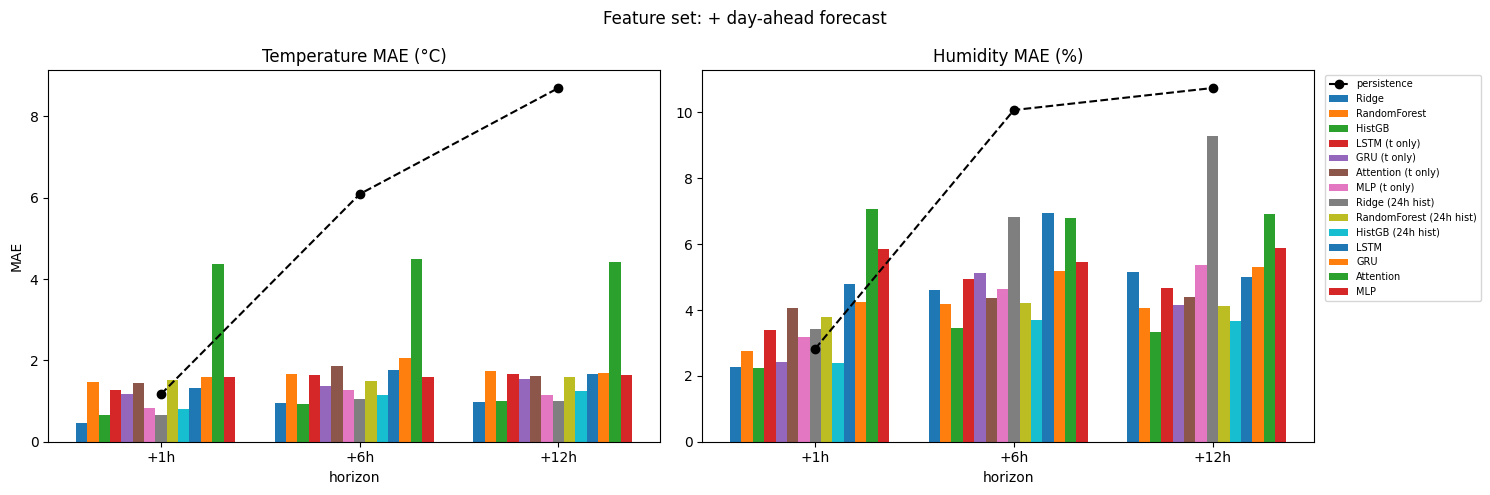

In [31]:
fs_show = "+ day-ahead forecast"   # now the richest rung
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, var, label in zip(axes, ["temp", "hum"],
                          ["Temperature MAE (°C)", "Humidity MAE (%)"]):
    cols = [f"{var}_h{h}" for h in (1, 6, 12)]
    x = np.arange(3); models = MODEL_ORDER; w = 0.8/len(models)
    for i, m in enumerate(models):
        ax.bar(x + i*w, results[(m, fs_show)].loc[cols, "MAE"].values, w, label=m)
    ax.plot(x + w*len(models)/2, baseline_scores.loc[cols, "MAE"].values,
            "k--o", label="persistence")
    ax.set_xticks(x + 0.4); ax.set_xticklabels(["+1h","+6h","+12h"])
    ax.set_title(label); ax.set_xlabel("horizon")
axes[0].set_ylabel("MAE"); axes[1].legend(bbox_to_anchor=(1.01,1), fontsize=7)
plt.suptitle(f"Feature set: {fs_show}"); plt.tight_layout(); plt.show()


**How to read this.** The gap between the bars and the dashed baseline is the value the model adds. At **+1h** persistence is already strong; at **+6h/+12h** the learned models pull clearly ahead by exploiting the daily cycle and the weather forecast.

## 2.11 — Predicted vs actual (best model overall)

All three horizons (**+1h / +6h / +12h**) for both **temperature** and **humidity** — every target the model predicts, not just a representative subset.


best (ranked by mean CVRMSE): ('HistGB', '+ day-ahead forecast') | mean CVRMSE = 0.048


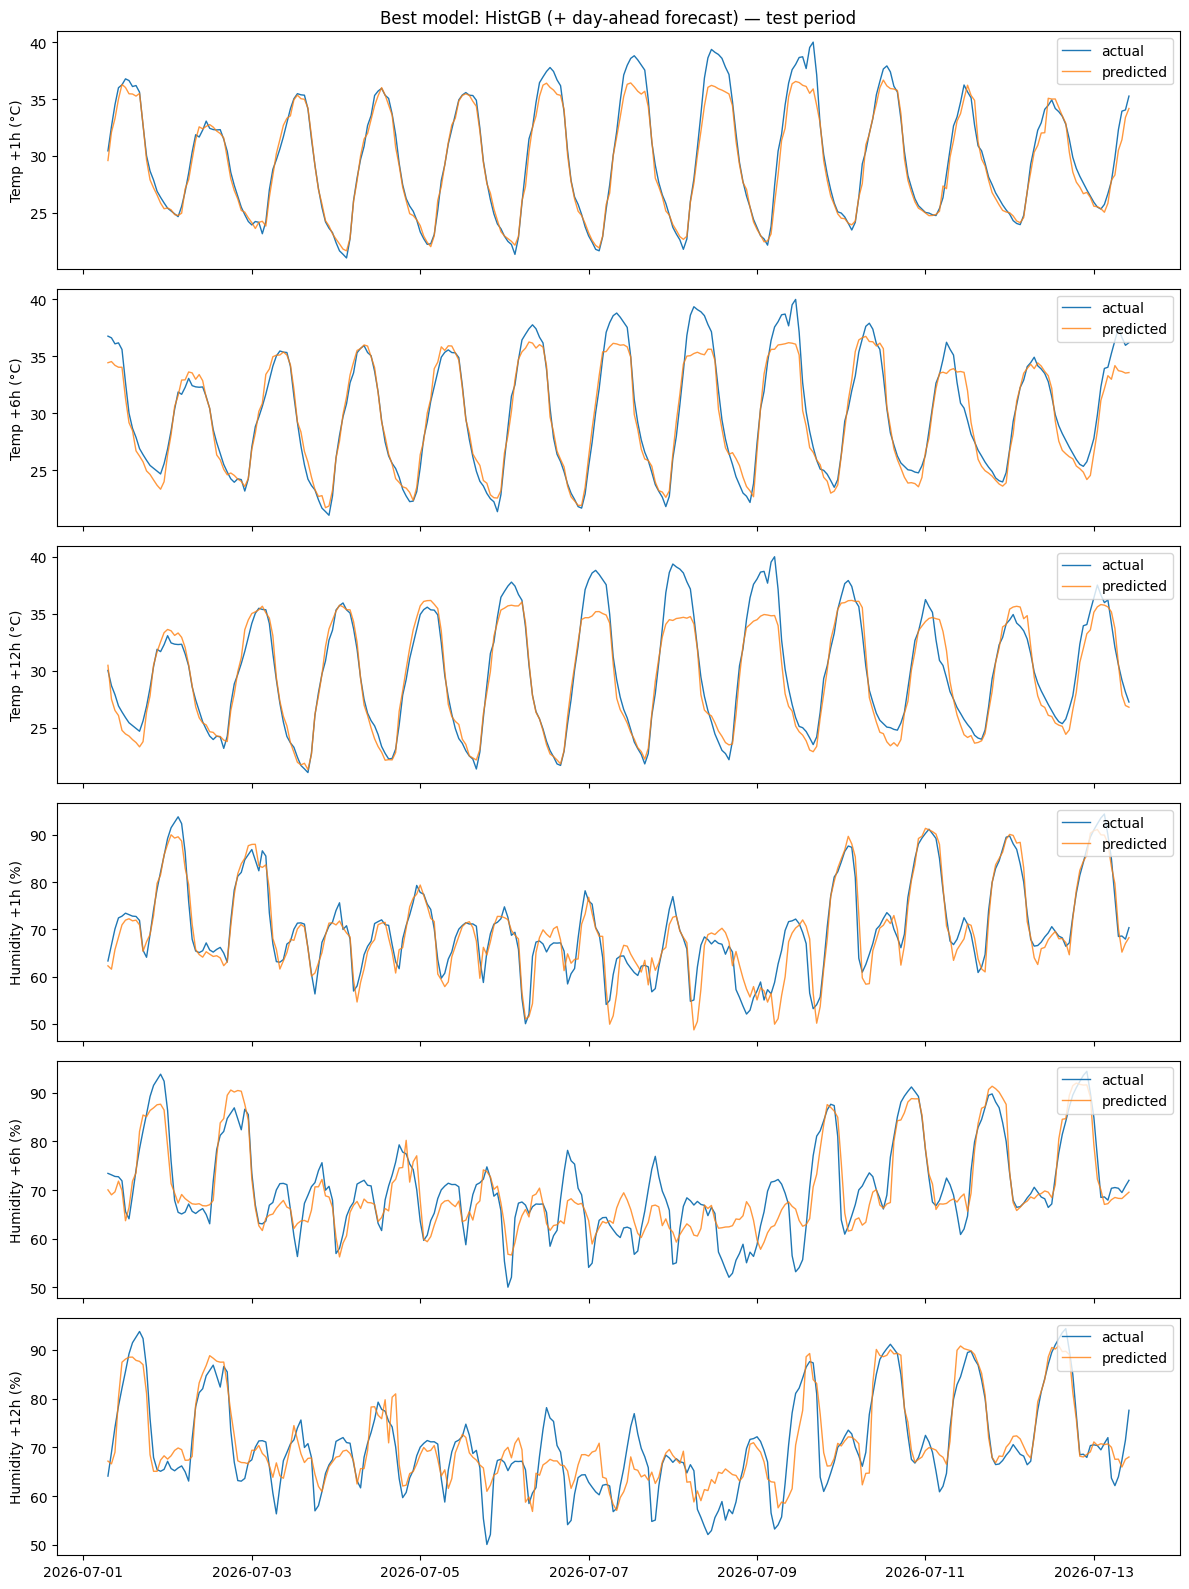

In [32]:
avg_cvrmse = {k: v["CVRMSE"].mean() for k, v in results.items()}
best_key = min(avg_cvrmse, key=avg_cvrmse.get)
print("best (ranked by mean CVRMSE):", best_key, "| mean CVRMSE =", round(avg_cvrmse[best_key], 3))
best_pred = predictions[best_key]

cols_to_plot = ["temp_h1", "temp_h6", "temp_h12", "hum_h1", "hum_h6", "hum_h12"]
labels = ["Temp +1h (°C)", "Temp +6h (°C)", "Temp +12h (°C)",
         "Humidity +1h (%)", "Humidity +6h (%)", "Humidity +12h (%)"]

fig, axes = plt.subplots(len(cols_to_plot), 1, figsize=(12, 16), sharex=True)
for ax, col, ylab in zip(axes, cols_to_plot, labels):
    ax.plot(test.index, y_test[col], label="actual", lw=1)
    ax.plot(test.index, best_pred[col], label="predicted", lw=1, alpha=0.8)
    ax.set_ylabel(ylab); ax.legend(loc="upper right")
axes[0].set_title(f"Best model: {best_key[0]} ({best_key[1]}) — test period")
plt.tight_layout(); plt.show()


## 2.12 — Feature importance, climatic systems highlighted

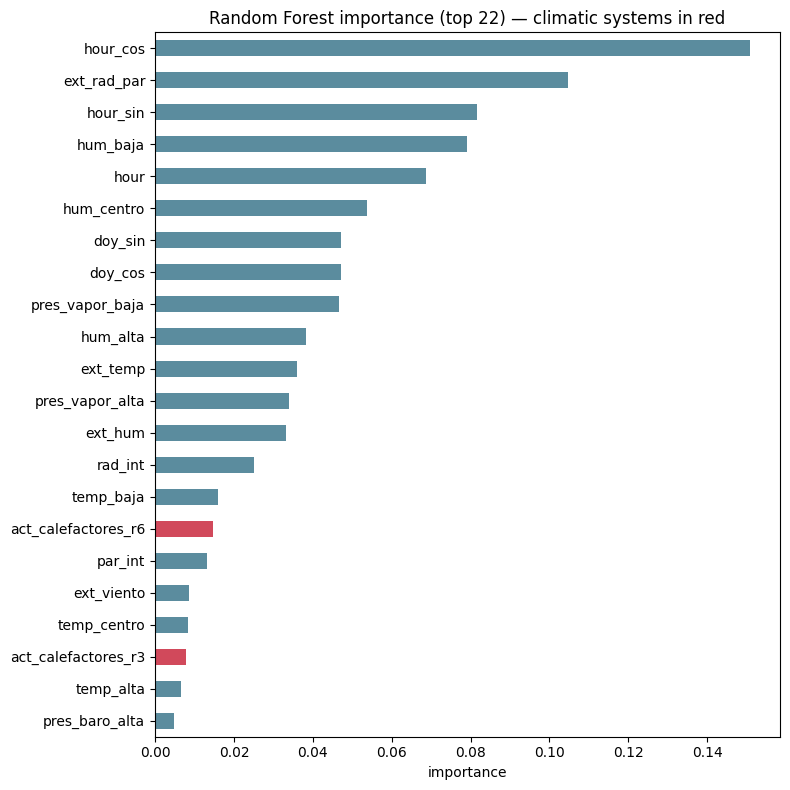

In [33]:
top = imp.head(22).iloc[::-1]
colors = ["#d1495b" if f in actuator_features else "#5b8c9e" for f in top.index]
top.plot(kind="barh", color=colors, figsize=(8, 8))
plt.title("Random Forest importance (top 22) — climatic systems in red")
plt.xlabel("importance"); plt.tight_layout(); plt.show()

### 2.12b — Permutation importance (test-set, generalization-based)

2.12's bars are **impurity-based** importance (`rf_imp.feature_importances_`, from 2.9): the mean decrease in variance credited to each feature across every split in the forest, computed while *fitting* on `train`. It says what the forest **used** to fit the training data — it doesn't measure what actually helps it generalize, and it's known to inflate high-cardinality/continuous features and split credit arbitrarily across correlated columns.

Permutation importance is a complementary, generalization-based measure of the *same, already-fitted* `rf_imp` model — **no new model is trained here, and nothing in 2.9/2.12 is recomputed or changed.** On the held-out `test` set, `sklearn.inspection.permutation_importance` repeatedly shuffles one feature column at a time and measures how much the model's score (`neg_mean_absolute_error`) drops. A feature the model actually relies on for accurate *test* predictions shows a large drop when shuffled; an unused or redundant one shows close to zero (or even a small positive "drop" from pure noise). `n_repeats=20` gives each feature a mean and a standard deviation, shown as error bars in the plot below.

Note the climatic-system "% share" figure below isn't directly comparable to 2.9/2.12's: impurity importance is non-negative and sums to a meaningful total by construction, while permutation importance can come out slightly negative for irrelevant features from pure noise — so the share here is computed over the *clipped-to-zero* positive importances only, as an approximation, not an exact analogue.


In [34]:
from sklearn.inspection import permutation_importance

# Reuses the exact `rf_imp` fitted in 2.9 (cell above 2.12) -- does not refit,
# does not touch `imp` / `act_share` / any other existing variable or result.
perm_cols = feature_sets["+ actuator history"]
perm_result = permutation_importance(
    rf_imp, test[perm_cols], y_test,
    scoring="neg_mean_absolute_error", n_repeats=20, random_state=0, n_jobs=-1)

perm_imp = pd.Series(perm_result.importances_mean, index=perm_cols).sort_values(ascending=False)
perm_imp_std = pd.Series(perm_result.importances_std, index=perm_cols)

act_share_perm = (perm_imp[actuator_features].clip(lower=0).sum()
                  / perm_imp.clip(lower=0).sum())
print(f"Climatic-system features hold {act_share_perm:.1%} of total (positive) permutation "
      f"importance on the test set -- compare with the {act_share:.1%} impurity-based figure in 2.9/2.12.")
print("Top climatic-system features by permutation importance:")
print(perm_imp[actuator_features].sort_values(ascending=False).head(8).round(4).to_string())


Climatic-system features hold 4.3% of total (positive) permutation importance on the test set -- compare with the 8.2% impurity-based figure in 2.9/2.12.
Top climatic-system features by permutation importance:
act_fog_r6                 0.0200
act_fog_r3                 0.0199
act_pantalla_cenital_r6    0.0127
act_pantalla_lat_sur_r3    0.0116
act_vent_lat_norte_r3      0.0116
act_pantalla_lat_sur       0.0087
act_pantalla_cenital_r3    0.0085
act_vent_lat_oeste_r6      0.0084


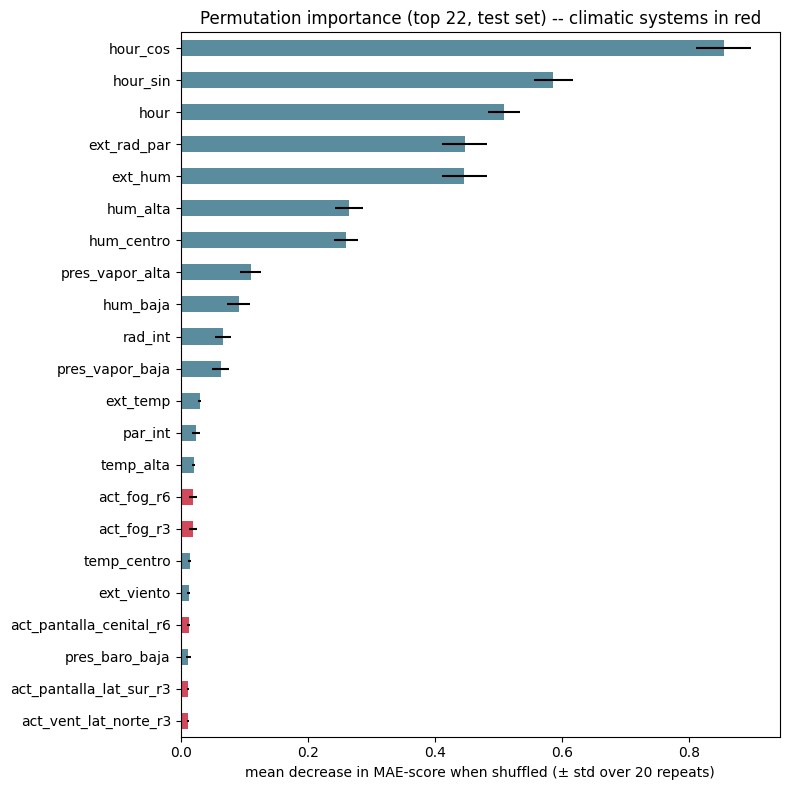

In [35]:
top_perm = perm_imp.head(22).iloc[::-1]
top_perm_std = perm_imp_std.reindex(top_perm.index)
colors_perm = ["#d1495b" if f in actuator_features else "#5b8c9e" for f in top_perm.index]
top_perm.plot(kind="barh", xerr=top_perm_std, color=colors_perm, figsize=(8, 8))
plt.title("Permutation importance (top 22, test set) -- climatic systems in red")
plt.xlabel("mean decrease in MAE-score when shuffled (\u00b1 std over 20 repeats)")
plt.tight_layout(); plt.show()


## 2.13 — Real vs. predicted Vapour Pressure Deficit (VPD)

VPD is a derived quantity, not a raw sensor — it is computed from temperature and humidity, so this checks whether the two per-target errors from the best model (selected by mean CVRMSE, see 2.8b/2.11) compound or cancel once combined into the value growers actually act on. **Real VPD** comes straight from `temp_centro` / `hum_centro` (via the h-hour-ahead targets, which are just those two columns shifted); **predicted VPD** uses the same model's temperature and humidity forecasts, at each horizon.

In [36]:
def vpd_kpa(temp_c, rh_pct):
    """Vapour pressure deficit (kPa) from temperature (°C) and relative humidity (%), Tetens equation."""
    es = 0.6108 * np.exp(17.27 * temp_c / (temp_c + 237.3))
    return es * (1 - rh_pct / 100.0)

horizons = (1, 6, 12)
vpd_real = pd.DataFrame({h: vpd_kpa(y_test[f"temp_h{h}"], y_test[f"hum_h{h}"]) for h in horizons})
vpd_best = pd.DataFrame({h: vpd_kpa(best_pred[f"temp_h{h}"], best_pred[f"hum_h{h}"]) for h in horizons})
vpd_real.columns.name = vpd_best.columns.name = "horizon (h)"

vpd_scores = pd.DataFrame({
    "MAE":    {h: mean_absolute_error(vpd_real[h], vpd_best[h]) for h in horizons},
    "CVRMSE": {h: cvrmse(vpd_real[h], vpd_best[h]) for h in horizons},
    "R2":     {h: r2_score(vpd_real[h], vpd_best[h]) for h in horizons},
})
vpd_scores.index.name = "horizon (h)"
print(f"VPD from best model: {best_key[0]} ({best_key[1]})  |  units: kPa for MAE, unitless for CVRMSE/R2")
vpd_scores.round(3)

VPD from best model: HistGB (+ day-ahead forecast)  |  units: kPa for MAE, unitless for CVRMSE/R2


,MAE,CVRMSE,R2
horizon (h),,,
1,0.117,0.138,0.910
6,0.159,0.173,0.860
12,0.162,0.182,0.845


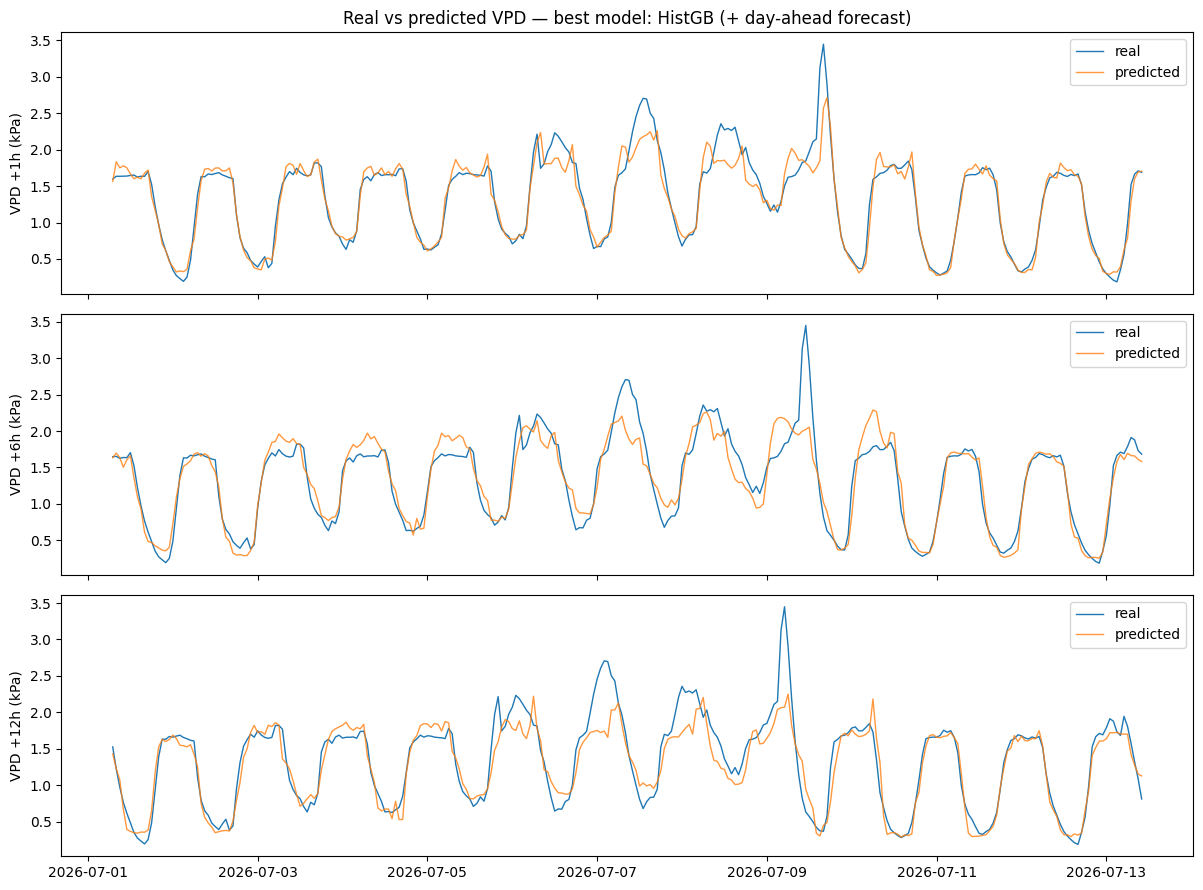

In [37]:
fig, axes = plt.subplots(len(horizons), 1, figsize=(12, 9), sharex=True)
for ax, h in zip(axes, horizons):
    ax.plot(test.index, vpd_real[h], label="real", lw=1)
    ax.plot(test.index, vpd_best[h], label="predicted", lw=1, alpha=0.8)
    ax.set_ylabel(f"VPD +{h}h (kPa)"); ax.legend(loc="upper right")
axes[0].set_title(f"Real vs predicted VPD — best model: {best_key[0]} ({best_key[1]})")
plt.tight_layout(); plt.show()

### 2.13b — Critical-VPD event detection (precision / recall / F1 / false-alarm rate / AUPRC)

The regression view above (MAE/CVRMSE/R2 on continuous VPD) doesn't say whether the model would actually catch a critical VPD event in time. This section reframes it as binary event detection, per horizon, for **two separate extremes**:

* **VPD too low** (`< VPD_LOW_KPA`) -- excess humidity, disease/fungal risk.
* **VPD too high** (`> VPD_HIGH_KPA`) -- plant water stress / stomatal closure risk.

**Thresholds.** `VPD_LOW_KPA` / `VPD_HIGH_KPA` below are **values from our greenhouse-VPD guidance**. They are fixed constants, set independently of the train/test split and never fit on any data, so there is no test-set leakage either way.

For each horizon and each extreme, the "alarm" is the model's own forecast crossing the *same* fixed threshold used for the real label -- i.e. the actual rule that would run in deployment, not a proxy derived from the regression error. **False-alarm rate** = FP / (FP + TN). **AUPRC** uses the continuous predicted VPD as the ranking score (average precision), so it's independent of exactly where the alarm threshold is drawn. `n_events` is reported alongside every row since a fixed threshold can yield zero positives in a ~295h test window at some horizons, in which case precision/recall/F1/AUPRC are not meaningful (shown as 0/NaN) -- this is a sample-size limitation of the placeholder thresholds on this dataset, not a code bug.

In [63]:
# PLACEHOLDER thresholds. Fixed as plain constants, independent of the
# train/test split, so swapping in the expert's numbers later only requires
# editing these two lines.
VPD_LOW_KPA = 0.4    # below this: high humidity, disease/fungal risk
VPD_HIGH_KPA = 1.6  # above this: water stress / stomatal closure risk

def vpd_event_scores(real, pred, low, high, kind):
    """kind: 'low' or 'high'. Binary event = real VPD crosses the fixed
    threshold; the model's own alarm uses the SAME threshold on its forecast."""
    real = np.asarray(real); pred = np.asarray(pred)
    if kind == "low":
        y_true = (real < low).astype(int)
        y_pred = (pred < low).astype(int)
        y_score = -pred   # more negative predicted VPD => more "low"-like
    else:
        y_true = (real > high).astype(int)
        y_pred = (pred > high).astype(int)
        y_score = pred    # higher predicted VPD => more "high"-like

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    far = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    n_events = int(y_true.sum())
    if n_events == 0 or n_events == len(y_true):
        auprc = np.nan   # undefined with a single-class horizon -- flag, don't fake a number
    else:
        auprc = average_precision_score(y_true, y_score)

    return {
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "False-alarm rate": far,
        "AUPRC": auprc,
        "n_events": n_events,
    }

vpd_event_low = pd.DataFrame(
    {h: vpd_event_scores(vpd_real[h], vpd_best[h], VPD_LOW_KPA, VPD_HIGH_KPA, "low") for h in horizons}).T
vpd_event_low.index.name = "horizon (h)"
print(f"Critical-VPD event detection -- LOW VPD (< {VPD_LOW_KPA} kPa), model: {best_key[0]} ({best_key[1]})")
display(vpd_event_low.round(3))

vpd_event_high = pd.DataFrame(
    {h: vpd_event_scores(vpd_real[h], vpd_best[h], VPD_LOW_KPA, VPD_HIGH_KPA, "high") for h in horizons}).T
vpd_event_high.index.name = "horizon (h)"
print(f"Critical-VPD event detection -- HIGH VPD (> {VPD_HIGH_KPA} kPa), model: {best_key[0]} ({best_key[1]})")
vpd_event_high.round(3)

Critical-VPD event detection -- LOW VPD (< 0.4 kPa), model: HistGB (+ day-ahead forecast)


,Precision,Recall,F1,False-alarm rate,AUPRC,n_events
horizon (h),,,,,,
1,0.857,0.96,0.906,0.015,0.958,25.0
6,0.724,0.84,0.778,0.030,0.808,25.0
12,0.667,0.96,0.787,0.045,0.758,25.0


Critical-VPD event detection -- HIGH VPD (> 1.6 kPa), model: HistGB (+ day-ahead forecast)


,Precision,Recall,F1,False-alarm rate,AUPRC,n_events
horizon (h),,,,,,
1,0.970,0.914,0.941,0.026,0.985,140.0
6,0.969,0.872,0.918,0.026,0.986,141.0
12,0.965,0.810,0.881,0.026,0.982,137.0


## 2.14 — Deployment information regimes: persistence / snapshot / historical / NWP / oracle

Sections 2.3-2.9 build a **feature ablation** -- turning individual feature groups (actuators, actuator history, cluster, day-ahead forecast) on and off within a fixed model. That answers "does this particular group of columns help?", but it conflates several different things: it never isolates *how much information is even allowed* at prediction time from *which architecture is used*. This section adds the complementary, explicit comparison across **deployability tiers** of information:

| regime | what's allowed |
|---|---|
| **persistence** | nothing learned -- tomorrow looks like now (2.6 baseline) |
| **snapshot** | information available *at* time *t* only: current interior climate + exterior weather + time-of-day + current actuator on-minutes + the cluster label (itself computed from the current snapshot alone, see notebook 1) -- **no** history, **no** forecast |
| **historical** | snapshot **+** observations up to time *t*: rolling actuator history (`hist_cols`) for the engineered features, and the raw 24h lookback window for the sequence architectures -- corresponds to the `+ cluster` rung already computed in 2.7-2.9, reused here (not retrained) |
| **NWP** | historical **+** the `previous_day1` weather forecast (issued ~1 day ahead, so already known at *t* for every horizon here) -- corresponds to the `+ day-ahead forecast` rung, reused here (not retrained) |
| **oracle** | historical **+** the *actual* future exterior weather (`ext_temp`/`ext_hum`/`ext_rad_par`/`ext_viento`, shifted to the target hour) **in place of** the forecast -- not deployable (you can't know the real future), it's an upper-bound benchmark that isolates the cost of forecast uncertainty: `NWP` vs `oracle` shows how much error is attributable to the forecast being imperfect rather than to the model |

**Design choices, explicit:**
* The cluster label is placed in **snapshot**, not historical: notebook 1 assigns each hour's cluster from that hour's own state alone (interior climate + actuators + exterior weather + time, no lookback), so it adds no information beyond what's already available at *t*.
* **snapshot only uses the `(t only)` / `lookback=1` variant of every architecture.** The `(24h hist)` tabular models and the 24h-lookback sequence models see 24 raw past hours *by construction*, regardless of which engineered columns are in `cols` -- including that window would silently turn "snapshot" into "historical" for those architectures. `historical`/`NWP`/`oracle` keep both the `(t only)` and `(24h hist)`/24h-lookback variants, since observing history (in either engineered or raw form) is exactly what those regimes allow.
* **oracle replaces the forecast rather than adding to it** -- mixing both would let a model pick whichever is more convenient and blur the "cost of forecast uncertainty" reading.
* **historical and NWP are not retrained** -- they reuse the exact predictions already computed for the `+ cluster` / `+ day-ahead forecast` rungs (2.7-2.8), so this section adds no redundant training for those two regimes. Since 2.3 now drops any row lacking a genuine future exterior-weather observation *before* the 2.4 train/test split (not after, as an earlier version of this notebook did), those 2.7-2.8 predictions were themselves already trained on the exact same `train` used below for `snapshot`/`oracle` -- all four non-persistence regimes share one row set end to end, not just at evaluation time.
* Every architecture in `MODEL_ORDER` (tabular, LSTM, GRU, Attention, MLP, each `t only` / `24h hist` where applicable) is trained fresh for `snapshot` and `oracle` -- this is the expensive part of this section (KerasTuner Bayesian search x 4 neural architectures x up to 2 lookback variants x 2 new regimes, plus the tabular small-grid searches), so budget real time for it.

### 2.14a -- Row set already shared with the rest of the notebook

A few hours have a genuine gap in the *raw* exterior-weather sensors (not the forecast) that is longer than the short-gap fill in `greenhouse_dataset.py`, so their *actual future* value is unavailable for `oracle`. That trim now happens in **2.3**, folded into the same `dropna()` that already excludes rows missing the day-ahead forecast columns -- so it runs *before* the 2.4 train/test split, and every section in this notebook (2.6 onward) already reflects it. This cell just confirms that and rebuilds the persistence reference used below (identical to the 2.6 baseline, since it's now the same `test`).


In [39]:
# oracle_hist_cols was already computed and folded into the shared dropna in 2.3 -- nothing
# to drop or rejoin here. Just confirm it, since a lot of this section's reasoning (and 2.14b's
# table below) depends on train/test already matching the rest of the notebook exactly.
assert set(oracle_hist_cols).issubset(data.columns), "expected oracle_hist_cols to already be in `data` from 2.3"
assert not data[oracle_hist_cols].isna().any().any(), "expected the 2.3 dropna to have removed every oracle gap already"
print(f"oracle_hist_cols present and gap-free in data/train/test -- {len(train)} train / {len(test)} test rows, "
     f"identical to every other section in this notebook.")

# Same test rows as the 2.6 baseline now, so no need to recompute persistence separately.
persistence_scores = baseline_scores


oracle_hist_cols present and gap-free in data/train/test -- 1164 train / 292 test rows, identical to every other section in this notebook.


In [40]:
def fit_all_architectures(cols, label, include_24h=True):
    """Train every architecture in this notebook's grid on ONE feature list `cols`,
    for the information-regime comparison -- reuses every helper already defined
    in 2.7 (`model_search_space`/`fit_best`, `make_sequences`, `tune_neural`, and
    the four `make_*` builders) so the fitting logic is identical to 2.7b-2.7k,
    just parameterised by `cols` instead of `feature_sets`. Stores nothing in the
    global `results`/`predictions` dicts -- returns its own (r, p) dicts instead,
    kept separate from the feature-ablation ladder's results by design.

    `include_24h=False` (used for `snapshot`) trains ONLY the `(t only)` /
    `lookback=1` variant of every architecture: the `(24h hist)` tabular models
    and the 24h-lookback sequence models see 24 raw past hours by construction,
    which would silently turn "snapshot" into "historical" regardless of which
    engineered columns are in `cols`.
    """
    r, p = {}, {}

    for m_name, (ctor, grid) in model_search_space().items():
        model, _ = fit_best(ctor, grid, train[cols], y_train)
        pred = pd.DataFrame(model.predict(np.asarray(test[cols])), index=test.index, columns=TARGET_COLS)
        r[m_name] = score(y_test, pred); p[m_name] = pred

    if include_24h:
        Xtr_seq, ytr, Xte_seq, y_scaler, _ = make_sequences(cols)
        Xtr_flat, Xte_flat = Xtr_seq.reshape(len(Xtr_seq), -1), Xte_seq.reshape(len(Xte_seq), -1)
        for m_name, (ctor, grid) in model_search_space().items():
            model, _ = fit_best(ctor, grid, Xtr_flat, ytr)
            pred = pd.DataFrame(y_scaler.inverse_transform(model.predict(Xte_flat)),
                                index=test.index, columns=TARGET_COLS)
            key = f"{m_name} (24h hist)"
            r[key] = score(y_test, pred); p[key] = pred

    for arch_name, make_fn in [("LSTM", make_lstm), ("GRU", make_gru),
                               ("Attention", make_attention), ("MLP", make_mlp)]:
        if include_24h:
            Xtr, ytr, Xte, y_scaler, _ = make_sequences(cols)
            model, _ = tune_neural(make_fn, n_features=Xtr.shape[-1], n_targets=len(TARGET_COLS),
                                   lookback=LOOKBACK, Xtr=Xtr, ytr=ytr,
                                   project_name=f"{arch_name.lower()}_24h_regime_{_safe_name(label)}")
            pred = pd.DataFrame(y_scaler.inverse_transform(model.predict(Xte, verbose=0)),
                                index=test.index, columns=TARGET_COLS)
            r[arch_name] = score(y_test, pred); p[arch_name] = pred

        Xtr0, ytr0, Xte0, y_scaler0, _ = make_sequences(cols, lookback=1)
        model0, _ = tune_neural(make_fn, n_features=Xtr0.shape[-1], n_targets=len(TARGET_COLS),
                                lookback=1, Xtr=Xtr0, ytr=ytr0,
                                project_name=f"{arch_name.lower()}_tonly_regime_{_safe_name(label)}")
        pred0 = pd.DataFrame(y_scaler0.inverse_transform(model0.predict(Xte0, verbose=0)),
                             index=test.index, columns=TARGET_COLS)
        key0 = f"{arch_name} (t only)"
        r[key0] = score(y_test, pred0); p[key0] = pred0

    tag = "" if include_24h else " (t-only architectures only -- by regime definition, see markdown above)"
    print(f"[{label}] trained {len(r)} model variants{tag}")
    return r, p

In [41]:
regime_results, regime_predictions = {}, {}

r_snap, p_snap = fit_all_architectures(climate + ACTUATOR_COLS + cluster_cols, "snapshot", include_24h=False)
for m_name in r_snap:
    regime_results[(m_name, "snapshot")] = r_snap[m_name]
    regime_predictions[(m_name, "snapshot")] = p_snap[m_name]

r_orac, p_orac = fit_all_architectures(
    climate + ACTUATOR_COLS + hist_cols + cluster_cols + oracle_hist_cols, "oracle", include_24h=True)
for m_name in r_orac:
    regime_results[(m_name, "oracle")] = r_orac[m_name]
    regime_predictions[(m_name, "oracle")] = p_orac[m_name]

# historical / NWP: reuse the already-trained "+ cluster" / "+ day-ahead forecast" predictions
# (no retraining), rescored on this section's row set so all five regimes are comparable.
for m_name in MODEL_ORDER:
    hist_pred = predictions[(m_name, "+ cluster")].loc[test.index]
    nwp_pred = predictions[(m_name, "+ day-ahead forecast")].loc[test.index]
    regime_results[(m_name, "historical")] = score(y_test, hist_pred)
    regime_predictions[(m_name, "historical")] = hist_pred
    regime_results[(m_name, "NWP")] = score(y_test, nwp_pred)
    regime_predictions[(m_name, "NWP")] = nwp_pred

print("regime_results now holds", len(regime_results), "(model, regime) entries")

c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsirisWater\Lib\site-packages\keras\src\ops\nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsirisWater\Lib\site-packages\keras\src\ops\nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(
c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsirisWater\Lib\site-packages\keras\src\ops\nn.py:947: UserWarning: You are using a softmax over axis 3 of a tensor of shape (None, 4, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is 

[snapshot] trained 7 model variants (t-only architectures only -- by regime definition, see markdown above)


c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsirisWater\Lib\site-packages\sklearn\linear_model\_ridge.py:265: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.37442536135768e-08.
  dual_coef = linalg.solve(K, y, assume_a="pos", overwrite_a=False)
c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsirisWater\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsirisWater\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter length_scale is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
c:\Users\psyey\OneDrive\Escritorio\Git_repos\venvOsi

[oracle] trained 14 model variants
regime_results now holds 49 (model, regime) entries


### 2.14b -- The five-regime comparison

Rows = every architecture in `MODEL_ORDER` (plus `persistence`); columns = the four non-trivial regimes. `NaN` marks an architecture/regime combination that doesn't exist **by definition** (e.g. `LSTM (24h hist)`-style entries have no `snapshot` counterpart, since `snapshot` only trains `(t only)` architectures -- see 2.14). Compare `historical` against `snapshot` for the value of observing the past at all; `NWP` against `historical` for the value of the day-ahead forecast; and `NWP` against `oracle` for how much of the remaining error is attributable to the forecast being imperfect rather than to the model itself.

In [42]:
def regime_mean_metric(m, rg, metric, cols=None):
    key = (m, rg)
    if key not in regime_results:
        return np.nan
    s = regime_results[key][metric]
    return s.loc[cols].mean() if cols is not None else s.mean()

REGIME_ORDER = ["snapshot", "historical", "NWP", "oracle"]

# Never average raw MAE across temperature (degC) and humidity (%RH) -- same
# convention as 2.8. CVRMSE (next cell) is the unitless ranking metric.
print("Information-regime comparison (mean MAE, temperature only, degC):")
regime_ladder_mae_temp = pd.DataFrame(
    {rg: {m: regime_mean_metric(m, rg, "MAE", TEMP_TARGET_COLS) for m in MODEL_ORDER} for rg in REGIME_ORDER})
regime_ladder_mae_temp.loc["persistence"] = persistence_scores["MAE"].loc[TEMP_TARGET_COLS].mean()
display(regime_ladder_mae_temp.round(3))

print("Information-regime comparison (mean MAE, humidity only, %RH):")
regime_ladder_mae_hum = pd.DataFrame(
    {rg: {m: regime_mean_metric(m, rg, "MAE", HUM_TARGET_COLS) for m in MODEL_ORDER} for rg in REGIME_ORDER})
regime_ladder_mae_hum.loc["persistence"] = persistence_scores["MAE"].loc[HUM_TARGET_COLS].mean()
regime_ladder_mae_hum.round(3)

Information-regime comparison (mean MAE, temperature only, degC):


,snapshot,historical,NWP,oracle
Ridge,1.225,1.180,0.800,0.856
RandomForest,1.626,1.680,1.626,1.625
HistGB,1.039,1.071,0.856,0.707
LSTM (t only),1.939,1.654,1.525,1.408
GRU (t only),1.733,1.627,1.362,1.272
Attention (t only),1.522,1.567,1.638,1.385
MLP (t only),1.296,1.269,1.085,1.155
Ridge (24h hist),NaN,1.082,0.900,0.814
RandomForest (24h hist),NaN,1.632,1.531,1.449
HistGB (24h hist),NaN,1.295,1.067,0.808


Information-regime comparison (mean MAE, humidity only, %RH):


,snapshot,historical,NWP,oracle
Ridge,5.586,5.787,4.014,4.785
RandomForest,4.193,4.280,3.662,3.253
HistGB,3.801,3.781,3.011,2.393
LSTM (t only),4.830,4.865,4.335,4.015
GRU (t only),4.952,4.992,3.902,3.583
Attention (t only),4.721,5.156,4.271,4.337
MLP (t only),4.793,4.453,4.392,4.258
Ridge (24h hist),NaN,7.572,6.503,5.449
RandomForest (24h hist),NaN,4.535,4.031,3.657
HistGB (24h hist),NaN,3.864,3.246,2.352


In [43]:
print("Information-regime comparison (mean CVRMSE across targets -- unitless, the ranking metric):")
regime_ladder_cvrmse = pd.DataFrame(
    {rg: {m: regime_mean_metric(m, rg, "CVRMSE") for m in MODEL_ORDER} for rg in REGIME_ORDER})
regime_ladder_cvrmse.loc["persistence"] = persistence_scores["CVRMSE"].mean()
regime_ladder_cvrmse.round(3)

Information-regime comparison (mean CVRMSE across targets -- unitless, the ranking metric):


,snapshot,historical,NWP,oracle
Ridge,0.076,0.076,0.053,0.059
RandomForest,0.075,0.077,0.069,0.066
HistGB,0.060,0.061,0.048,0.041
LSTM (t only),0.084,0.080,0.071,0.066
GRU (t only),0.080,0.080,0.063,0.060
Attention (t only),0.075,0.082,0.072,0.068
MLP (t only),0.071,0.068,0.062,0.061
Ridge (24h hist),NaN,0.089,0.074,0.064
RandomForest (24h hist),NaN,0.076,0.070,0.065
HistGB (24h hist),NaN,0.066,0.054,0.042


In [44]:
print("Information-regime comparison (mean R2 across targets):")
regime_ladder_r2 = pd.DataFrame(
    {rg: {m: regime_mean_metric(m, rg, "R2") for m in MODEL_ORDER} for rg in REGIME_ORDER})
regime_ladder_r2.loc["persistence"] = persistence_scores["R2"].mean()
regime_ladder_r2.round(3)

Information-regime comparison (mean R2 across targets):


,snapshot,historical,NWP,oracle
Ridge,0.627,0.596,0.818,0.759
RandomForest,0.722,0.712,0.785,0.807
HistGB,0.790,0.785,0.881,0.916
LSTM (t only),0.660,0.686,0.756,0.790
GRU (t only),0.686,0.682,0.802,0.828
Attention (t only),0.722,0.666,0.755,0.767
MLP (t only),0.725,0.744,0.790,0.803
Ridge (24h hist),NaN,0.386,0.600,0.707
RandomForest (24h hist),NaN,0.721,0.774,0.807
HistGB (24h hist),NaN,0.776,0.857,0.917


## 2.15 -- Final model comparison plots

Visual companions to the tables above, all read off the same
already-computed results (nothing is retrained here): (a) the mean-CVRMSE
ranking at the richest feature-ablation rung (2.8/2.8c); (b) the same metric
across the five deployment information regimes (2.14b), so the
architecture-vs-information-regime distinction is visible at a glance; (c)
the 5-seed mean +/- std for every neural architecture (2.7m), the plot to
check before reading any bar-height difference in (a)/(b) as a real
architecture effect rather than seed noise; and (d) the critical-VPD
event-detection scores (2.13b) for both extremes, by horizon.

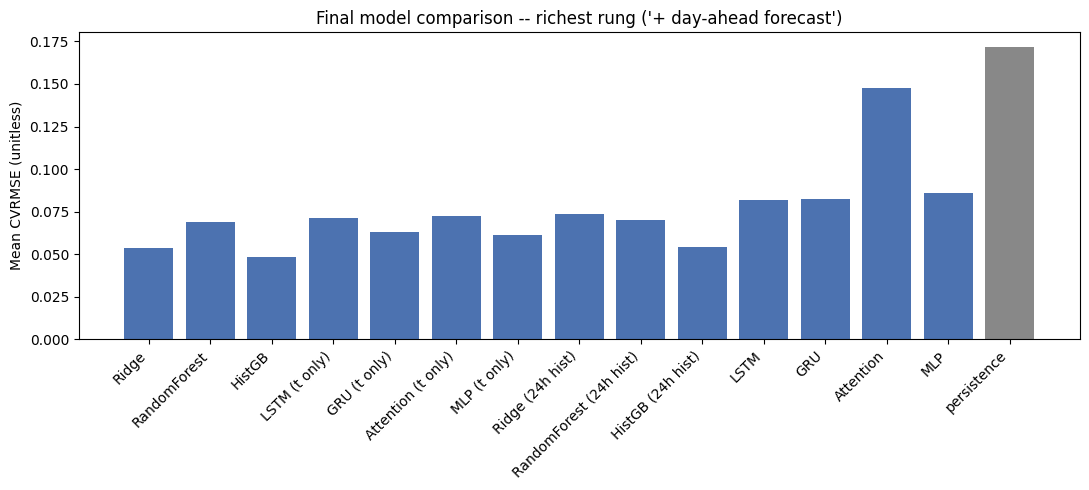

In [45]:
fs_plot = fs_best  # richest feature-ablation rung, "+ day-ahead forecast" (2.8c)
cvrmse_final = pd.Series({m: results[(m, fs_plot)]["CVRMSE"].mean() for m in MODEL_ORDER})
cvrmse_final["persistence"] = baseline_scores["CVRMSE"].mean()

fig, ax = plt.subplots(figsize=(11, 5))
bar_colors = ["#4C72B0"] * len(MODEL_ORDER) + ["#888888"]
ax.bar(cvrmse_final.index.astype(str), cvrmse_final.values, color=bar_colors)
ax.set_ylabel("Mean CVRMSE (unitless)")
ax.set_title(f"Final model comparison -- richest rung ('{fs_plot}')")
ax.tick_params(axis="x", rotation=45)
for lbl in ax.get_xticklabels():
    lbl.set_ha("right")
plt.tight_layout()
plt.show()

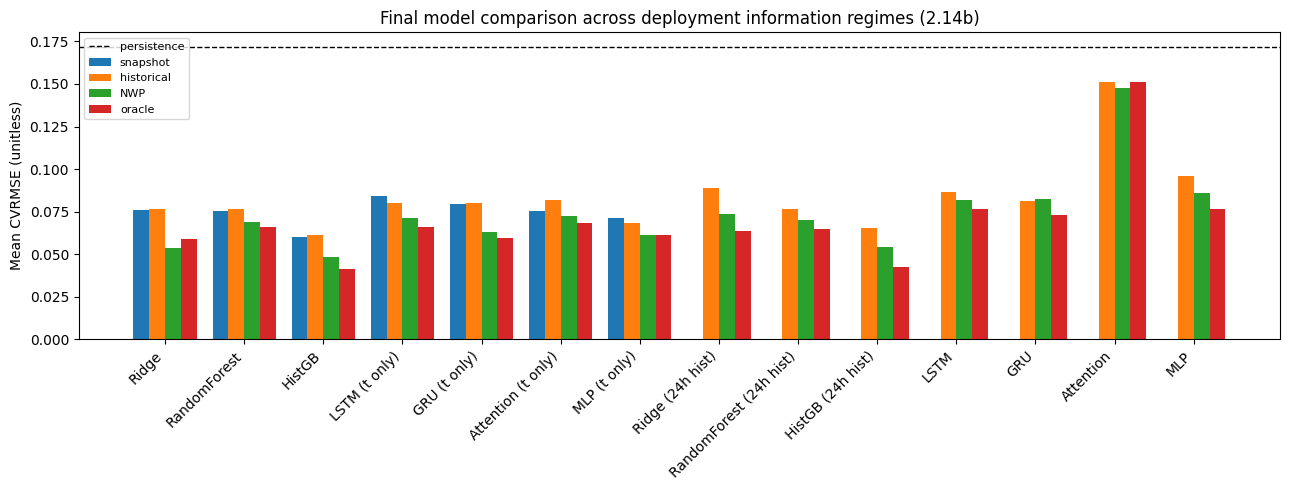

In [46]:
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(MODEL_ORDER))
width = 0.8 / len(REGIME_ORDER)
for i, rg in enumerate(REGIME_ORDER):
    vals = [regime_mean_metric(m, rg, "CVRMSE") for m in MODEL_ORDER]
    ax.bar(x + i * width, vals, width, label=rg)
ax.axhline(persistence_scores["CVRMSE"].mean(), color="k", linestyle="--", linewidth=1, label="persistence")
ax.set_xticks(x + width * (len(REGIME_ORDER) - 1) / 2)
ax.set_xticklabels(MODEL_ORDER, rotation=45, ha="right")
ax.set_ylabel("Mean CVRMSE (unitless)")
ax.set_title("Final model comparison across deployment information regimes (2.14b)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

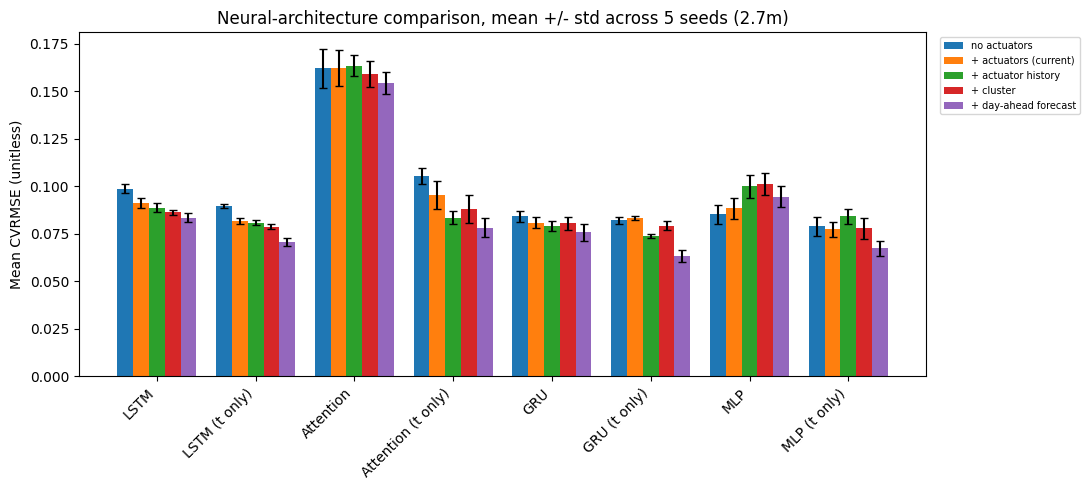

In [49]:
neural_names = list(dict.fromkeys(k[0] for k in results_seeds))
fs_list = list(feature_sets)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(neural_names))
width = 0.8 / len(fs_list)
for i, fs in enumerate(fs_list):
    means, stds = [], []
    for m in neural_names:
        key = (m, fs)
        if key in results_seeds:
            vals = [s["CVRMSE"].mean() for s in results_seeds[key]]
            means.append(np.mean(vals)); stds.append(np.std(vals))
        else:
            means.append(np.nan); stds.append(0.0)
    ax.bar(x + i * width, means, width, yerr=stds, capsize=3, label=fs)
ax.set_xticks(x + width * (len(fs_list) - 1) / 2)
ax.set_xticklabels(neural_names, rotation=45, ha="right")
ax.set_ylabel("Mean CVRMSE (unitless)")
ax.set_title(f"Neural-architecture comparison, mean +/- std across {len(SEED_REPEATS)} seeds (2.7m)")
ax.legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

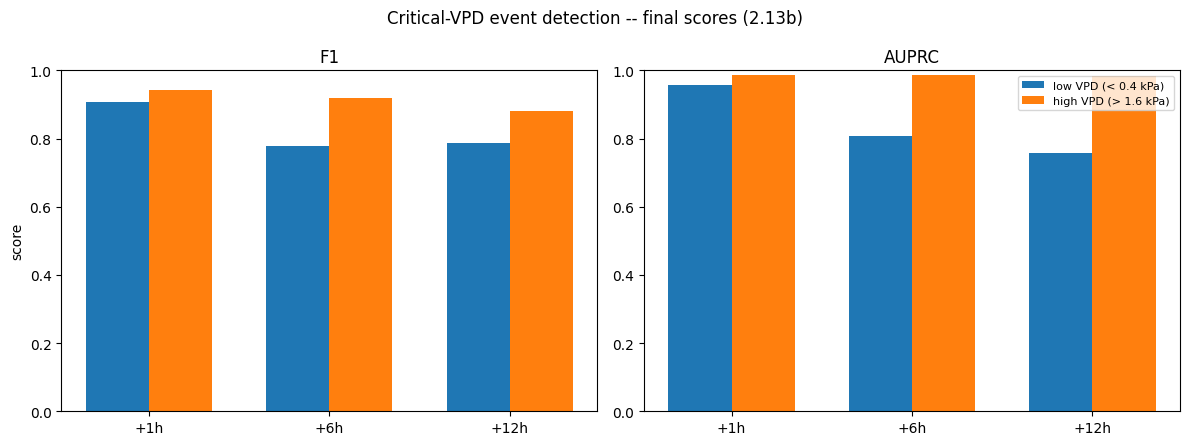

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = np.arange(len(horizons)); w = 0.35
for ax, metric in zip(axes, ["F1", "AUPRC"]):
    ax.bar(x - w / 2, vpd_event_low[metric], w, label=f"low VPD (< {VPD_LOW_KPA} kPa)")
    ax.bar(x + w / 2, vpd_event_high[metric], w, label=f"high VPD (> {VPD_HIGH_KPA} kPa)")
    ax.set_xticks(x); ax.set_xticklabels([f"+{h}h" for h in horizons])
    ax.set_title(metric); ax.set_ylim(0, 1)
axes[0].set_ylabel("score")
axes[1].legend(fontsize=8)
plt.suptitle("Critical-VPD event detection -- final scores (2.13b)")
plt.tight_layout()
plt.show()

## Summary & next steps

* Interior **temperature + humidity** at **+1h / +6h / +12h** framed as one multi-output regression, scoped to the period where all climatic systems operate.
* All learned models beat persistence, the advantage **growing with horizon**; gradient boosting / random forest are strongest among the single-timestep tabular models.
* **Full 5×2 architecture comparison (2.7b–2.7k).** Ridge/RandomForest/HistGB, the LSTM, a GRU, a compact attention-based (Transformer-encoder) model, and a plain MLP are each trained twice — once single-timestep, once on the flattened/sequential 24h window — so the ladder in 2.8 separates several questions at once: does *history* help (compare a model against its own "(24h hist)"/"(t only)" counterpart), do the *recurrent* architectures (LSTM, GRU) help over tabular models given the same information, does *attention* help over either of them, and does any of that beat a plain *MLP* fed the exact same window (isolating "having 24h of raw history" from "actually modelling order"). With ~1.2k training hours all four neural architectures are data-hungry relative to the tabular models, so none is guaranteed to win — see the ladder (2.8) and best-model report (2.8b) for how they actually compare once you run the notebook.
* **Attention model is intentionally a scaled-down TFT-style block, not a full Temporal Fusion Transformer** (see 2.7f for the reasoning) — one multi-head self-attention layer plus a small feed-forward block, at a parameter budget close to the LSTM's, so the comparison is about the *attention mechanism* rather than the extra machinery (variable-selection networks, gating, quantile loss) a production TFT would add.
* **Hyperparameter tuning for all models, Bayesian for the neural ones (2.7b–2.7k).** Ridge/RandomForest/HistGB search a small fixed grid; every neural architecture (LSTM, GRU, Attention, MLP) is tuned by KerasTuner's `BayesianOptimization` (`tune_neural()`, 2.7d) over `units`, `dropout`, learning rate and `optimizer` — a real mixed continuous/categorical search rather than a hand-picked list, still scored on a chronological hold-out inside `train` so it can't see `test`. 2.7l shows exactly what won for each model × rung (e.g. a much larger Ridge `alpha` on the "(24h hist)" rungs signals how much more regularisation that higher columns-to-rows ratio needs; a Bayesian search consistently landing on non-zero `dropout` for a neural model would suggest it was overfitting at `dropout=0`).
* **Day-ahead forecast, aligned per horizon (2.1/2.3).** The `+ day-ahead forecast` rung adds, for each horizon, the `previous_day1` Open-Meteo forecast value for the *target* hour — a forecast genuinely known about a day in advance, unlike the un-suffixed `fc_*` columns, which are excluded from every model input (see the note in 2.3). The 2.9b ablation cell measures its marginal value the same way the actuator ablation does.
* The **climatic-system features** (heaters, fog, vents, screens, pumps…) are fully included and — once scoped and given rolling **history** — become the most-used engineered features (double-digit importance share). However the **ablation shows they add little forecasting accuracy**, because their effect is already reflected in the interior sensors.
* **New: 2.14 separates deployment information regimes from the feature ablation (2.3–2.9).** The ladder in 2.3–2.9 is a feature-by-feature ablation within a fixed architecture; 2.14 instead compares **persistence / snapshot (info at *t*) / historical (observations up to *t*) / NWP (forecast issued ≤ *t*) / oracle (the actual future exterior weather)** explicitly, across every architecture in the grid above. The gap between `NWP` and `oracle` isolates how much error is attributable to forecast uncertainty rather than to the model itself -- something the original ladder had no way to show, since it never included an oracle regime at all.
* **Model selection no longer averages raw MAE across degC and %RH.** `fit_best()`'s internal hyperparameter search, and every "best model" pick (2.8b, 2.11, 2.14), now rank by **mean CVRMSE** (unitless) instead of mean MAE over the 6 mixed-unit target columns. MAE is still reported, but always split into temperature-only and humidity-only tables (2.8, 2.14b), never averaged across the two. Also reinstated a fix that had been agreed on earlier but never made it into this file: `score()` and the VPD scores were still computing R² as squared Pearson correlation (`np.corrcoef(...)**2`) rather than the true coefficient of determination -- both now use `sklearn.metrics.r2_score`.
* **New: 2.13b adds critical-VPD event detection.** Beyond the continuous regression view, 2.13b defines "VPD too low" / "VPD too high" as two separate binary events per horizon against fixed, literature-placeholder thresholds (`VPD_LOW_KPA` / `VPD_HIGH_KPA`, pending the agronomy expert's validated numbers), and reports precision, recall, F1, false-alarm rate and AUPRC for each -- not just whether the continuous forecast is close, but whether it would have caught the event.
* **New: 2.7m repeats every neural architecture over 5 seeds and reports parameter counts.** Each of LSTM/GRU/Attention/MLP's already-tuned winning hyperparameters is refit from scratch under `SEED_REPEATS = (0,1,2,3,4)` and scored, so the architecture comparison in 2.8/2.10/2.11 can be read as mean +/- std instead of one (possibly lucky-or-unlucky) run. Parameter counts per model x rung are also reported, since all four architectures share the same `units` search range but that does **not** mean equal parameter budgets (e.g. the MLP's flattened-input layer scales with `lookback x n_features`, unlike the recurrent layers' fixed-size gates) -- so no claim that one architecture "beats" or "underperforms" another should be read as settled until it holds up against both of these.
* **Fixed: seed-repeat refits (2.7m) weren't actually varying the seed.** Each `make_lstm`/`make_gru`/`make_attention`/`make_mlp` hardcoded `keras.utils.set_random_seed(0)` as its first line, so the per-iteration `keras.utils.set_random_seed(seed)` call in `refit_with_seeds` was immediately overwritten the moment the model-builder ran -- every "seed" in `SEED_REPEATS` was silently reinitializing from seed 0, so the mean+/-std numbers only reflected residual, unseeded TF/Keras nondeterminism rather than real initialization/training-randomness sensitivity. Each builder now takes a `seed=0` parameter (`tune_neural`'s hyperparameter search still always uses the default `seed=0`, unchanged) and `refit_with_seeds` passes its loop seed through explicitly, so the 2.7m/2.15 seed-variability numbers need a rerun to reflect this fix.
* **Fixed: `oracle`/`snapshot` were trained on a slightly smaller row set than `historical`/`NWP` in 2.14.** The rows lacking a genuine future exterior-weather observation (needed only for `oracle`) used to be dropped in 2.14a, *after* `historical`/`NWP`'s underlying `+ cluster` / `+ day-ahead forecast` predictions had already been trained in 2.7-2.8 on the larger, untrimmed `train` -- so all four non-persistence regimes were compared on the same *test* rows, but not the same *training* rows. That drop now happens in **2.3**, folded into the same `dropna()` that already excludes rows missing the day-ahead forecast columns, before the 2.4 train/test split -- so every section in this notebook from 2.6 onward (including the 2.7-2.13 grid whose predictions 2.14 reuses) already reflects the final row set. 2.14a is now just a confirmation, not a second trim, and `persistence_scores` there is simply the 2.6 baseline (same `test` now, no need to recompute it separately). One consequence worth flagging: every table from 2.6 onward now runs on a handful fewer rows than an earlier version of this notebook, since the oracle-gap rows are excluded everywhere, not just from 2.14 -- rerun the notebook top to bottom to get consistent numbers.

**Ideas to push further**
* **Control / what-if model:** predict the *change* in temperature/humidity caused by opening a vent or running fog — here the actuators are the *inputs you set*, so they become decisive (this is where the climatic-system data pays off most).
* `max_trials=8` in `tune_neural()` is deliberately small to bound runtime; if 2.7l shows the neural models' winners are noisy or inconsistent across rungs, that's a signal the Bayesian search hasn't had enough trials to converge — raising `max_trials`, or switching to `kt.Hyperband` (which allocates its budget more adaptively across many cheap short runs plus a few longer ones), would be the next step before trusting the winners too much.
* If the attention model is competitive, a natural next step toward an actual TFT is adding the pieces skipped here: a variable-selection network (learned per-feature gating instead of feeding every column identically), separate handling of the day-ahead forecast columns as "known future inputs" versus the sensor columns as "observed past", and a quantile loss for uncertainty bands instead of a point MAE.
* Collect more than one season so the re-scoped window is larger and covers more regimes (would also help the LSTM, Attention, and the `(24h hist)` tabular models, which all benefit most from more training sequences).
* `TimeSeriesSplit` cross-validation (rather than a single inner hold-out) for a less noisy hyperparameter choice; try direct-vs-recursive multi-horizon strategies.
* Feed the control **rules** (`inside data/rules/`) as setpoint features.
